# Probabilistic top-down: coherent probabilistic forecasts for large hierarchies

Back in [m04](../m04-hierarchical-forecasting.ipynb) we met hierarchical forecasting: sales data lives at many levels of aggregation at once (total → department → item), and forecasts at those levels should *add up* — a property called **coherence**. The classical recipe is *forecast-then-reconcile*: produce a forecast for every series in the hierarchy, then adjust them so the sums work out. That recipe has two problems at retail scale. First, the bottom of the hierarchy is enormous (M5 has 30,490 item–store series; Favorita has 161,480) and mostly noise — intermittent count series that are zero on most days. Fitting a model to every one of them is expensive and thankless. Second, modern practice wants **probabilistic** forecasts (full predictive distributions, not just points), and the coherence requirement then applies to entire *joint* distributions: every simulated future scenario must satisfy the aggregation constraints, not just the means.

This notebook builds a minimal, from-scratch implementation of **e2eTD** — *end-to-end probabilistic top-down* — the method proposed by Zambon, Azzimonti and Corani (2026), ["End-to-end probabilistic hierarchical forecasting of large hierarchies via probabilistic top-down"](https://arxiv.org/abs/2606.26774) (arXiv:2606.26774). The idea is disarmingly simple:

1. **Select** a small sub-hierarchy of smooth *upper* series (in the paper, ~0.3% of the hierarchy) — these are the only series we actually forecast.
2. **Forecast** each selected upper series with a cheap univariate model (exponential smoothing).
3. **Reconcile** those few upper forecasts with each other, and draw joint samples at the lowest selected level.
4. **Disaggregate** each sample down to the bottom level with a novel *probabilistic top-down* sampler: instead of splitting a total with fixed historical proportions, the split is drawn at random from an in-sample joint distribution of the children (count marginals coupled by a copula), conditioned on the children summing to the total.
5. **Aggregate** the joint bottom-level samples back up to get coherent probabilistic forecasts for *every* level — coherent by construction, because every scenario literally adds up.

On the full M5 dataset this runs in under five minutes on a laptop and would have ranked 11th out of 892 teams in the M5 Uncertainty competition. We will reproduce the machinery on a slice of M5 we can comfortably run in seconds: one Walmart store (`CA_1`), one category (`HOBBIES`), which gives us a three-level hierarchy — 1 total, 2 departments, 565 items — with delightfully intermittent bottom series. Conveniently, the paper's own walk-through example is the `HOBBIES_1` department, so we are literally rebuilding the figure from the paper.

# Setup

In [1]:
# Standard library imports
import time
import warnings
import zipfile

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# Configuration & Settings
warnings.simplefilter(action='ignore')

We group the imports by origin, as usual. From the standard library we take `time` (to measure how long the top-down sampler runs — speed is half the point of this paper), `warnings` (to silence the harmless convergence chatter that exponential smoothing optimizers produce), and `zipfile` (the M5 sales file ships as a zip archive and we will read it without unpacking it to disk).

The third-party block is the familiar scientific stack. `numpy` (aliased `np`) does the array work, `pandas` (aliased `pd`) holds the time series tables, and `matplotlib.pyplot` (aliased `plt`) draws the figures. From `scipy` we import two things that carry the statistical weight of this notebook: `scipy.stats` provides frozen **Poisson** and **negative binomial** distributions — the count distributions we will fit to item demand — and `brentq` is a one-dimensional root finder we will use to invert the relationship between a copula parameter and a rank correlation. Finally, `ETSModel` from `statsmodels` is the exponential smoothing (ETS) implementation we use to forecast the few upper series; it is the same model family the paper uses.

The last line switches warnings off wholesale. The ETS optimizer likes to report every wobble of its likelihood surface; in a teaching notebook that noise would drown the outputs we actually want to read.

In [2]:
# general settings
class CFG:
    data_folder = '../data/'
    graph_folder = './graphs/'
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    STORE = 'CA_1'                     # the Walmart store we slice out of M5
    CATEGORY = 'HOBBIES'               # the product category (2 departments, 565 items)
    HORIZON = 28                       # forecast 28 days, as in the M5 competition
    N_SAMPLES = 500                    # joint sample paths per horizon
    HALF_LIFE = 28                     # exponential decay half-life for in-sample weights (days)
    QUANTILES = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

All the knobs of the notebook live in one `CFG` class, so a reader can change an experiment without hunting through cells. This notebook runs from the `hierarchical/` subfolder, so `data_folder` points one level up to the repo's shared `data/` directory.

The modelling constants mirror the paper's setup. `HORIZON = 28` is the M5 evaluation window: we hold out the last 28 days and forecast them. `N_SAMPLES = 500` is how many joint sample paths we draw per horizon — each sample is one complete simulated future for *all 565 items at once*, which is what "probabilistic and coherent" means in practice. `HALF_LIFE = 28` controls the recency weighting used when estimating the in-sample count distributions: an observation four weeks old gets half the weight of today's, which is the paper's simple heuristic for coping with slow drift. `QUANTILES` lists the nine quantile levels of the M5 Uncertainty competition; we will score every method with the pinball loss at exactly these levels.

The style block sets a consistent look and a large default figure size, and `np.random.seed(CFG.SEED)` pins the global random state so the notebook reproduces the same numbers on every run (we will also use dedicated `np.random.default_rng` generators for the sampling-heavy steps, each with a fixed seed).

# Utils

Three small helpers we will lean on throughout: recency weights, a count-distribution fitter, and the pinball loss.

In [3]:
def decay_weights(n, half_life=CFG.HALF_LIFE):
    """Exponential-decay weights over n observations; most recent weight = largest, sums to 1."""
    w = 0.5 ** (np.arange(n)[::-1] / half_life)
    return w / w.sum()

The probabilistic top-down step will summarize each pair of series by a *single* joint distribution estimated in-sample — no time series model at all. That is defensible because intermittent bottom series carry little temporal signal, but it would be reckless to weight a 2011 observation the same as a 2016 one. The paper's fix is an exponential decay: the weight of an observation halves every `half_life` days.

Mechanically, `np.arange(n)[::-1]` counts how many days ago each observation happened (the last row of the training data gets 0, the first gets `n-1`), `0.5 ** (age / half_life)` turns age into a geometric decay, and dividing by the sum normalizes the weights to add up to one, so they can be used directly as probabilities in weighted means. With a 28-day half-life and five years of history, effectively only the last few months matter — which is exactly the intent.

In [4]:
def fit_count_marginal(x, w):
    """Fit a Poisson or negative binomial to counts x by weighted moment matching."""
    mu = float(np.sum(w * x))
    var = float(np.sum(w * (x - mu) ** 2))
    mu = max(mu, 1e-9)
    if var <= mu * (1 + 1e-9):
        return stats.poisson(mu)
    r = mu ** 2 / (var - mu)
    p = r / (r + mu)
    return stats.nbinom(r, p)

This is the marginal-distribution estimator, and it is deliberately cheap. Given a count series `x` and recency weights `w`, we compute the weighted mean `mu` and the weighted variance `var` — that is the "moment matching" part: we pick the distribution whose first two moments equal the sample's.

The choice between the two count families rests on a classic diagnostic. A **Poisson** distribution has variance equal to its mean; real demand data is usually *overdispersed* (variance greater than mean, because demand comes in bursts). So: if `var <= mu` we return a frozen `stats.poisson(mu)`, otherwise a **negative binomial**. The NB is parameterized in scipy by a size `r` and success probability `p`; solving the NB moment equations (mean `r(1-p)/p`, variance `mean/p`) for our `mu, var` gives `r = mu²/(var−mu)` and `p = r/(r+mu)`.

Why moment matching instead of maximum likelihood? The paper benchmarks both: they give near-identical estimates, but moment matching is about two orders of magnitude faster — and e2eTD needs to fit roughly two marginals per internal node of a binary tree over 30k+ items, so estimator speed is a first-order design constraint. The `max(mu, 1e-9)` guard keeps items that never sold in the weighted window from producing a degenerate distribution.

In [5]:
def pinball(y, q, alpha):
    """Pinball (quantile) loss of forecast quantile q at level alpha against realization y."""
    return np.where(y >= q, alpha * (y - q), (1 - alpha) * (q - y))

The **pinball loss** is the standard way to score a quantile forecast. If we claim "the 97.5% quantile of tomorrow's demand is `q`", the loss penalizes us `alpha·(y−q)` when the realization `y` lands above our quantile (we were too low, and at high `alpha` that is a serious miss) and `(1−alpha)·(q−y)` when it lands below (we were too high, which at high `alpha` is only mildly penalized). The asymmetry is the point: it makes the *true* quantile the loss-minimizing answer, so a method can only win by being honestly calibrated. Averaging the pinball loss over the nine `CFG.QUANTILES` scores the whole predictive distribution; later we will also scale it per series, following the M5 Uncertainty competition's *weighted scaled pinball loss* (WSPL) recipe.

# The data: a slice of M5

M5 is daily unit sales for 3,049 products across 10 Walmart stores — the dataset the paper evaluates on. We carve out one store and one category, which keeps the hierarchy honest (intermittent bottoms, smooth top) while running in seconds.

In [6]:
with zipfile.ZipFile(CFG.data_folder + 'sales_train_evaluation.csv.zip') as z:
    with z.open('sales_train_evaluation.csv') as f:
        sales = pd.read_csv(f)
calendar = pd.read_csv(CFG.data_folder + 'calendar.csv')

print(sales.shape)
sales.head(3)

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


The M5 sales file is stored zipped (it is ~120 MB uncompressed), and the archive contains a stray macOS metadata entry, so a plain `pd.read_csv` of the zip path would complain about multiple files. Instead we open the archive with `zipfile.ZipFile`, grab the one member we want with `z.open`, and hand that file handle straight to `pd.read_csv` — pandas is happy to read from any file-like object, and nothing gets written to disk.

The table is in *wide* format: one row per item–store series, identifier columns (`item_id`, `dept_id`, `cat_id`, `store_id`, `state_id`) followed by 1,941 day columns `d_1 … d_1941`. The separate `calendar.csv` maps those day labels to actual dates (plus event flags we won't need here). The shape printout confirms 30,490 rows — the full M5 bottom level.

In [7]:
slice_df = sales[(sales['store_id'] == CFG.STORE) & (sales['cat_id'] == CFG.CATEGORY)].copy()
day_cols = [c for c in sales.columns if c.startswith('d_')]

dates = pd.to_datetime(calendar.set_index('d').loc[day_cols, 'date'])
bottom = pd.DataFrame(slice_df[day_cols].to_numpy().T,
                      index=dates.values, columns=slice_df['item_id'].to_numpy())
bottom.index.name = 'date'
dept_of = dict(zip(slice_df['item_id'], slice_df['dept_id']))

print(bottom.shape)
print(slice_df['dept_id'].value_counts().to_dict())
bottom.head(3)

(1941, 565)
{'HOBBIES_1': 416, 'HOBBIES_2': 149}


,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003,HOBBIES_1_004,HOBBIES_1_005,HOBBIES_1_006,HOBBIES_1_007,HOBBIES_1_008,HOBBIES_1_009,HOBBIES_1_010,...,HOBBIES_2_140,HOBBIES_2_141,HOBBIES_2_142,HOBBIES_2_143,HOBBIES_2_144,HOBBIES_2_145,HOBBIES_2_146,HOBBIES_2_147,HOBBIES_2_148,HOBBIES_2_149
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,0,0,0,0,0,0,0,12,2,0,...,0,0,2,0,0,0,0,0,0,0
2011-01-30,0,0,0,0,0,0,0,15,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-31,0,0,0,0,0,0,0,0,7,1,...,0,0,0,0,0,0,0,0,0,0


Here we build our working hierarchy. The boolean mask keeps only rows for store `CA_1` and category `HOBBIES` — 565 items split across two departments: 416 in `HOBBIES_1` and 149 in `HOBBIES_2` (the printout confirms it). Note the paper's own illustration of the top-down sampler uses exactly the 416 items of `HOBBIES_1`.

The next lines reshape wide to long-ish: we transpose the day-column block with `.to_numpy().T` so that *rows are dates and columns are items* — the natural orientation for time series work — and attach real dates by looking up each `d_x` label in the calendar (`pd.to_datetime` converts the date strings into proper timestamps). We also keep `dept_of`, a plain dictionary mapping each item to its department; it defines the hierarchy's structure — in aggregation-matrix language from m04, it is a very compact encoding of the matrix **A**. The `head(3)` sanity check shows what we will stare at for the rest of the notebook: rows of small integers, most of them zero.

In [8]:
train = bottom.iloc[:-CFG.HORIZON]
test = bottom.iloc[-CFG.HORIZON:]

depts = sorted(set(dept_of.values()))
items_by_dept = {d: [c for c in bottom.columns if dept_of[c] == d] for d in depts}

print('train:', train.shape, train.index[0].date(), '->', train.index[-1].date())
print('test :', test.shape, test.index[0].date(), '->', test.index[-1].date())

train: (1913, 565) 2011-01-29 -> 2016-04-24
test : (28, 565) 2016-04-25 -> 2016-05-22


The split is **chronological**, as always in this series: the last 28 days (`2016-04-25` to `2016-05-22`, the M5 evaluation window) are held out for testing, everything before (1,913 days from `2011-01-29`) is training. A random split would leak future information into the past and make the evaluation meaningless — we are simulating the real situation of standing at April 24, 2016 and forecasting the next four weeks.

We also precompute `items_by_dept`, the list of item columns belonging to each department, since we will aggregate items to departments many times over.

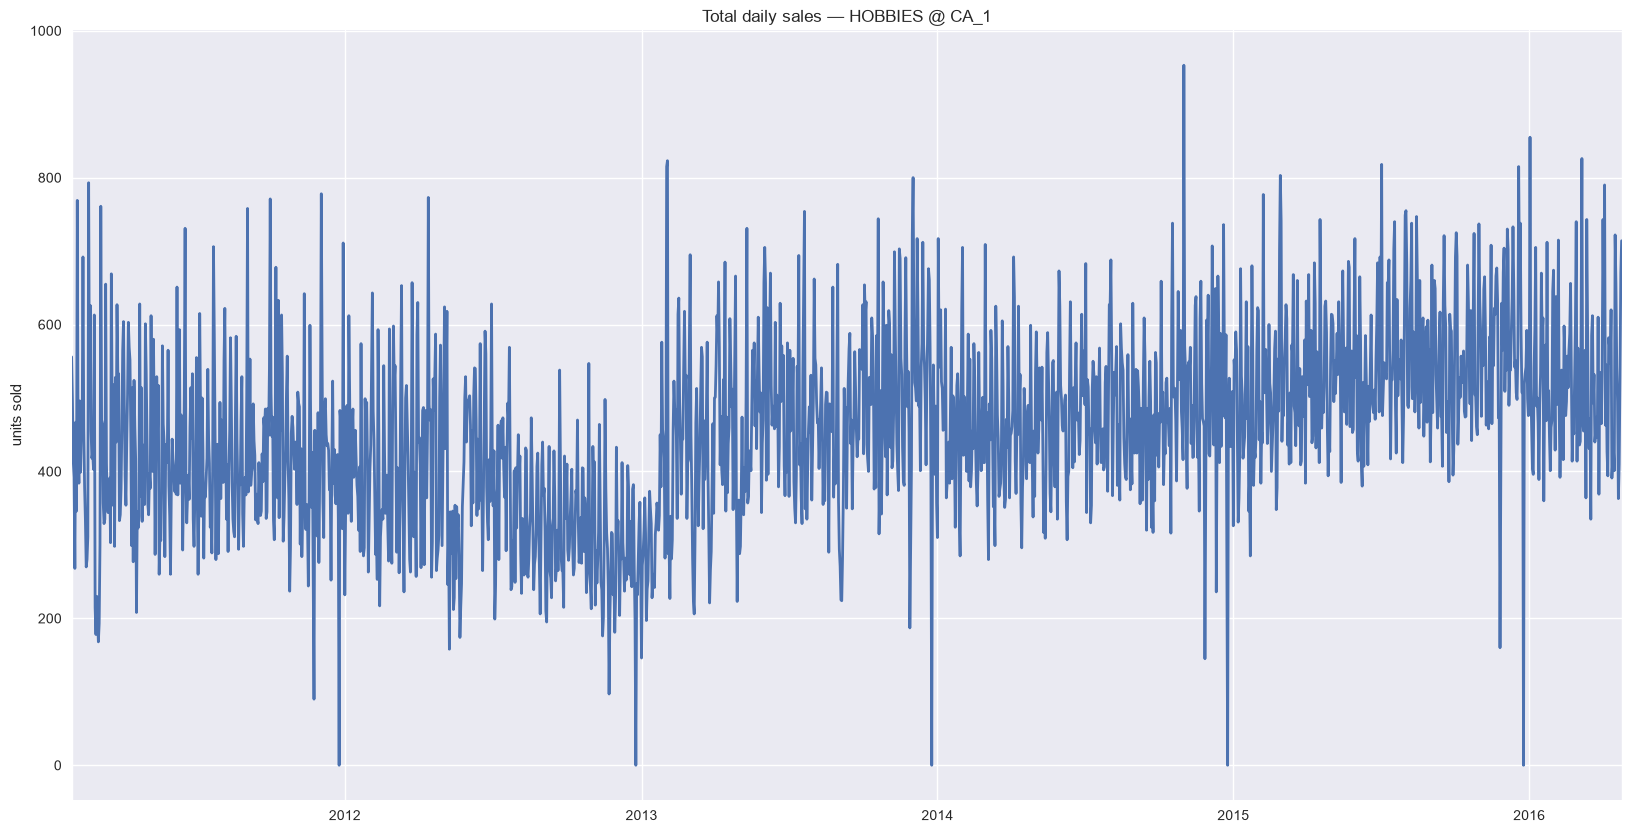

In [9]:
total_train = train.sum(axis=1)

total_train.plot(linewidth=2, xlabel='')
plt.title(f'Total daily sales — {CFG.CATEGORY} @ {CFG.STORE}')
plt.ylabel('units sold')
plt.show()

First look at the top of the hierarchy: `train.sum(axis=1)` adds all 565 items per day, and `.plot()` draws it. This series behaves like a *forecastable* time series: a clear level around 400–600 units, visible weekly ripples, some slow drift, occasional holiday dips (the deep spikes to zero are Christmas closures). Nothing exotic — exponential smoothing will handle it comfortably. Keep this picture in mind as the "smooth top"; the next plot shows what lives at the bottom.

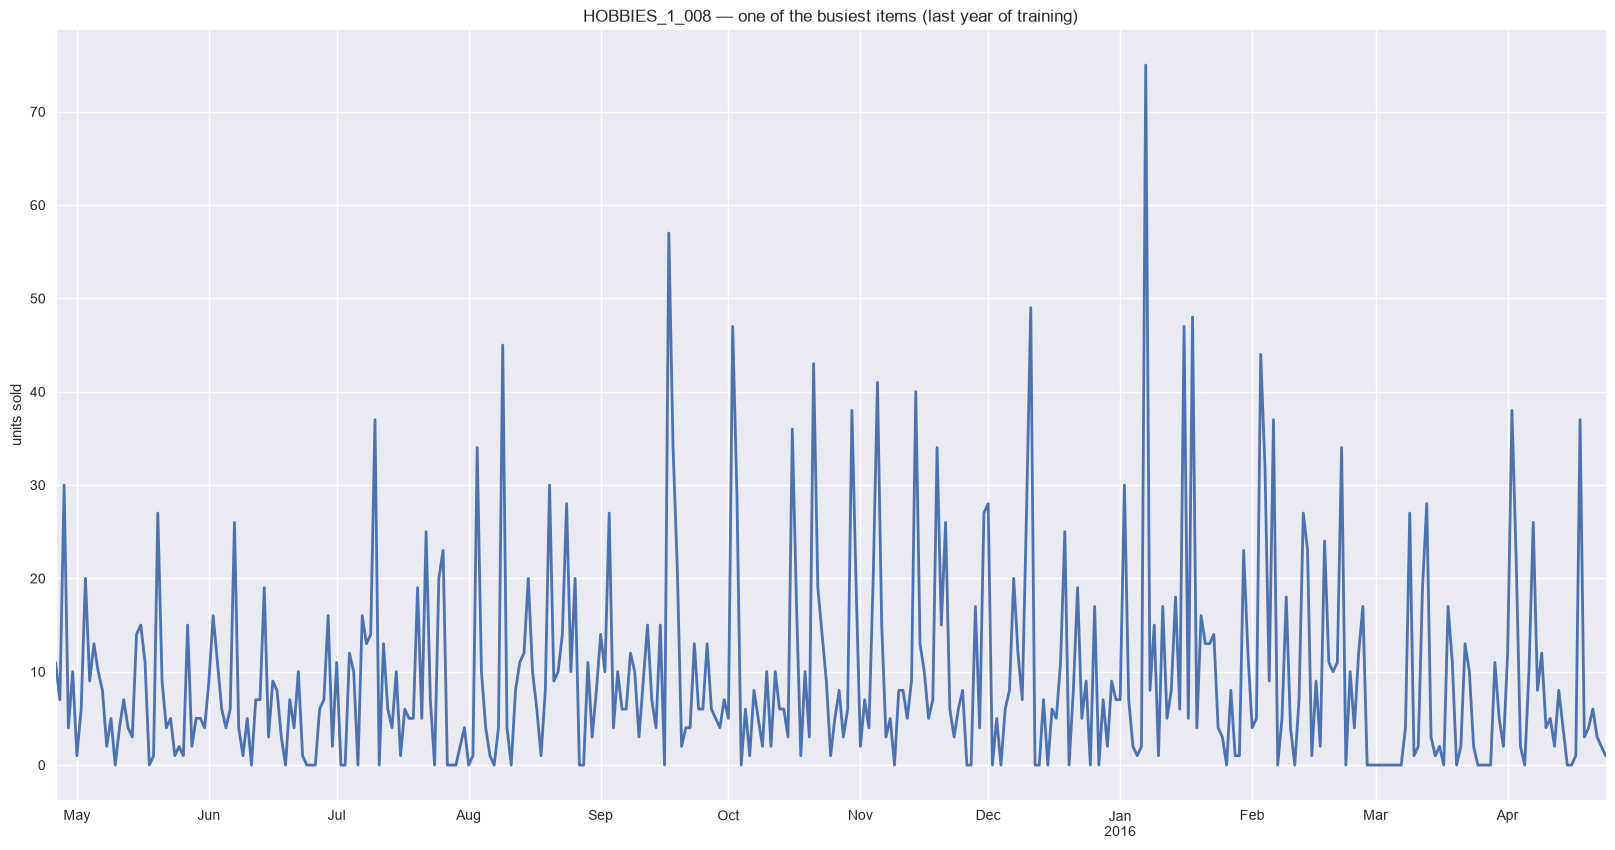

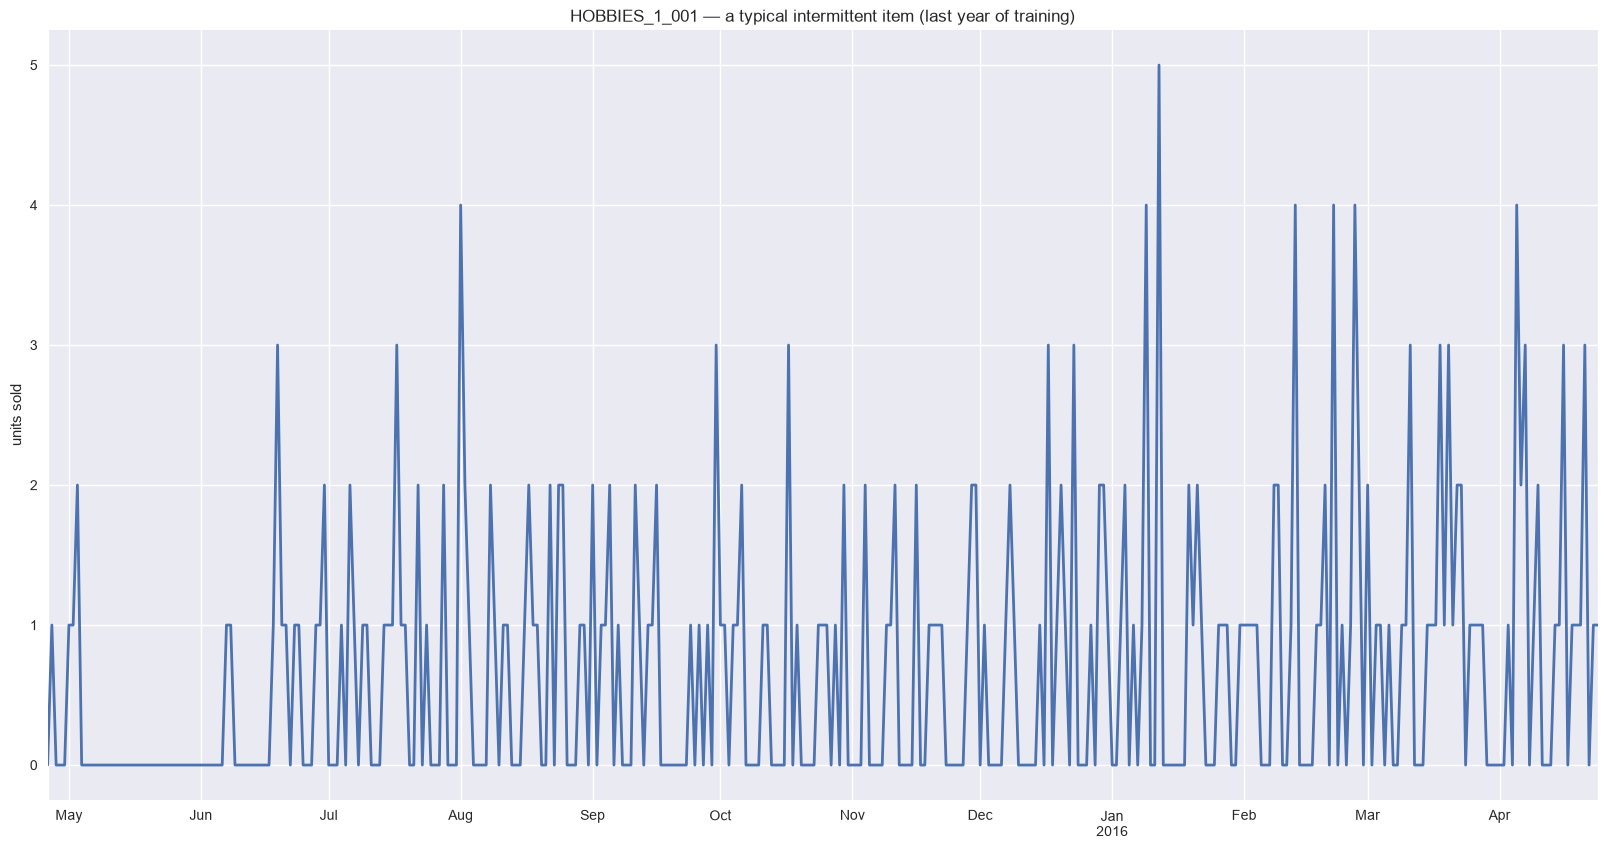

In [10]:
ITEM_SMOOTH = 'HOBBIES_1_008'
ITEM_SPIKY = 'HOBBIES_1_001'

plt.figure()
train[ITEM_SMOOTH].tail(365).plot(linewidth=2, xlabel='')
plt.title(f'{ITEM_SMOOTH} — one of the busiest items (last year of training)')
plt.ylabel('units sold')
plt.show()

plt.figure()
train[ITEM_SPIKY].tail(365).plot(linewidth=2, xlabel='')
plt.title(f'{ITEM_SPIKY} — a typical intermittent item (last year of training)')
plt.ylabel('units sold')
plt.show()

Two bottom-level series, plotted over the final training year. The first plot shows one of the rare high-volume items — even this "busy" series is jagged, but at least it has a level to track. The second plot is far more representative of the bottom level: zero on a large share of days, with demand arriving in sporadic bursts of one to four units (and this is one of the *livelier* intermittent items — the histogram in the next cell shows the median item is far sparser). There is essentially no temporal structure to model here; what *is* informative about such a series is its **distribution** — how often it is zero, how large the bursts are, and how it co-moves with its siblings. That observation is the philosophical core of e2eTD: don't waste models on the bottom; model the bottom's distributional behaviour and let the forecasting happen at the top.

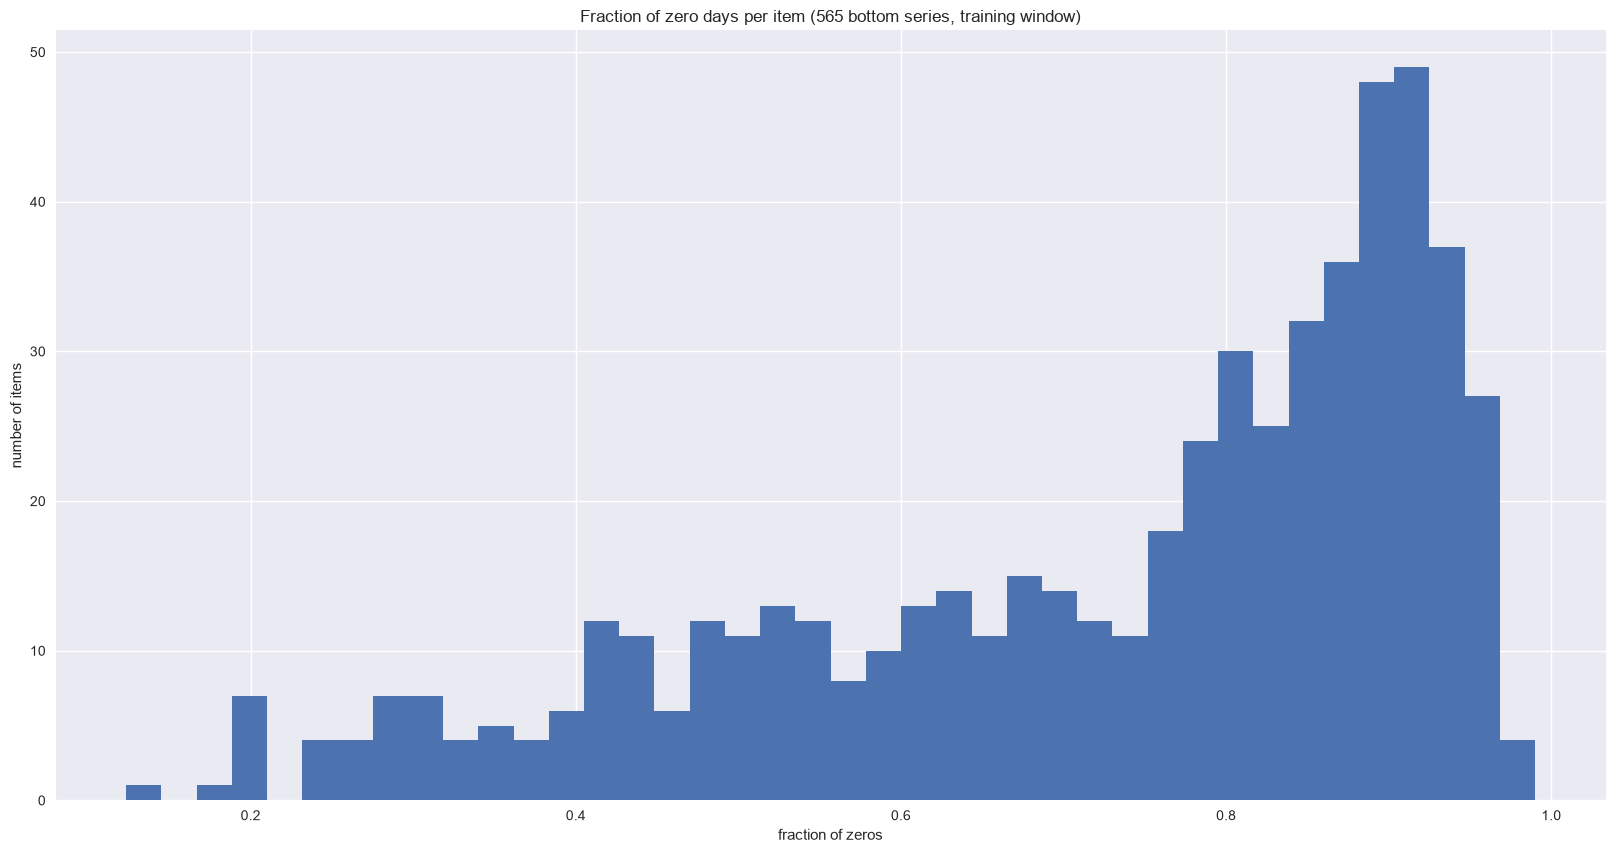

median fraction of zeros: 0.8
median mean daily demand: 0.31
fraction of zeros, total series: 0.0026


In [11]:
frac_zeros = (train == 0).mean()

frac_zeros.hist(bins=40)
plt.title('Fraction of zero days per item (565 bottom series, training window)')
plt.xlabel('fraction of zeros')
plt.ylabel('number of items')
plt.show()

print('median fraction of zeros:', round(frac_zeros.median(), 2))
print('median mean daily demand:', round(train.mean().median(), 2))
print('fraction of zeros, total series:', round((total_train == 0).mean(), 4))

How intermittent is our bottom level? `(train == 0).mean()` computes, for each item, the share of training days with zero sales; the histogram shows the whole distribution. The median item is at **80% zeros** and sells about **0.31 units per day** — squarely in intermittent-demand territory. Contrast the total series: zero on only ~0.3% of days (the Christmas closures). Aggregation has manufactured a smooth, forecastable signal out of hundreds of unforecastable ones. The paper's Figure 6 shows the same picture for the full M5 and Favorita datasets; our slice is faithful to it.

# The ingredients

Before assembling the pipeline, we build and inspect its three statistical ingredients: recency-weighted count marginals, the Plackett copula that glues two marginals into a joint distribution, and the conditional sampler that splits a total between two children.

## Count marginals by weighted moment matching

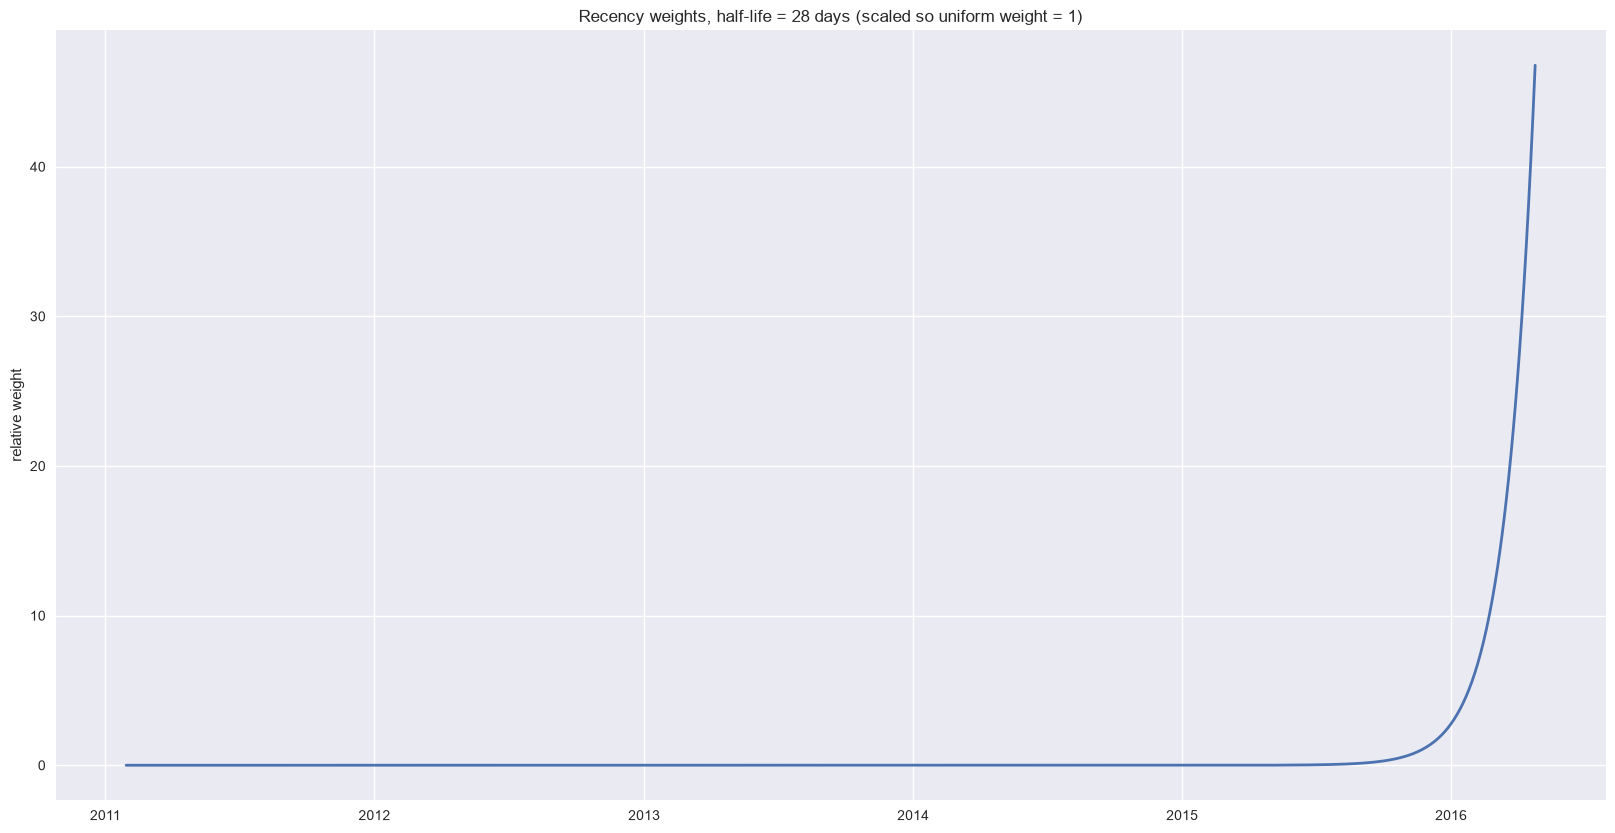

weight mass in the last 28 days : 0.5
weight mass in the last 90 days : 0.892


In [12]:
w_demo = decay_weights(len(train))

plt.plot(train.index, w_demo * len(train), linewidth=2)
plt.title(f'Recency weights, half-life = {CFG.HALF_LIFE} days (scaled so uniform weight = 1)')
plt.ylabel('relative weight')
plt.show()

print('weight mass in the last 28 days :', round(w_demo[-28:].sum(), 3))
print('weight mass in the last 90 days :', round(w_demo[-90:].sum(), 3))

A look at the decay weights over our five-year training window (scaled by `len(train)` so that a value of 1 would mean "same as uniform weighting"). The curve is essentially zero until late 2015 and then climbs steeply: the last 28 days carry half of the total weight, the last 90 days about 90% of it. The estimator sees five years of data but effectively *believes* the last quarter — a crude but serviceable answer to non-stationarity, and one of the paper's explicitly acknowledged simplifications (they suggest more principled treatments as future work).

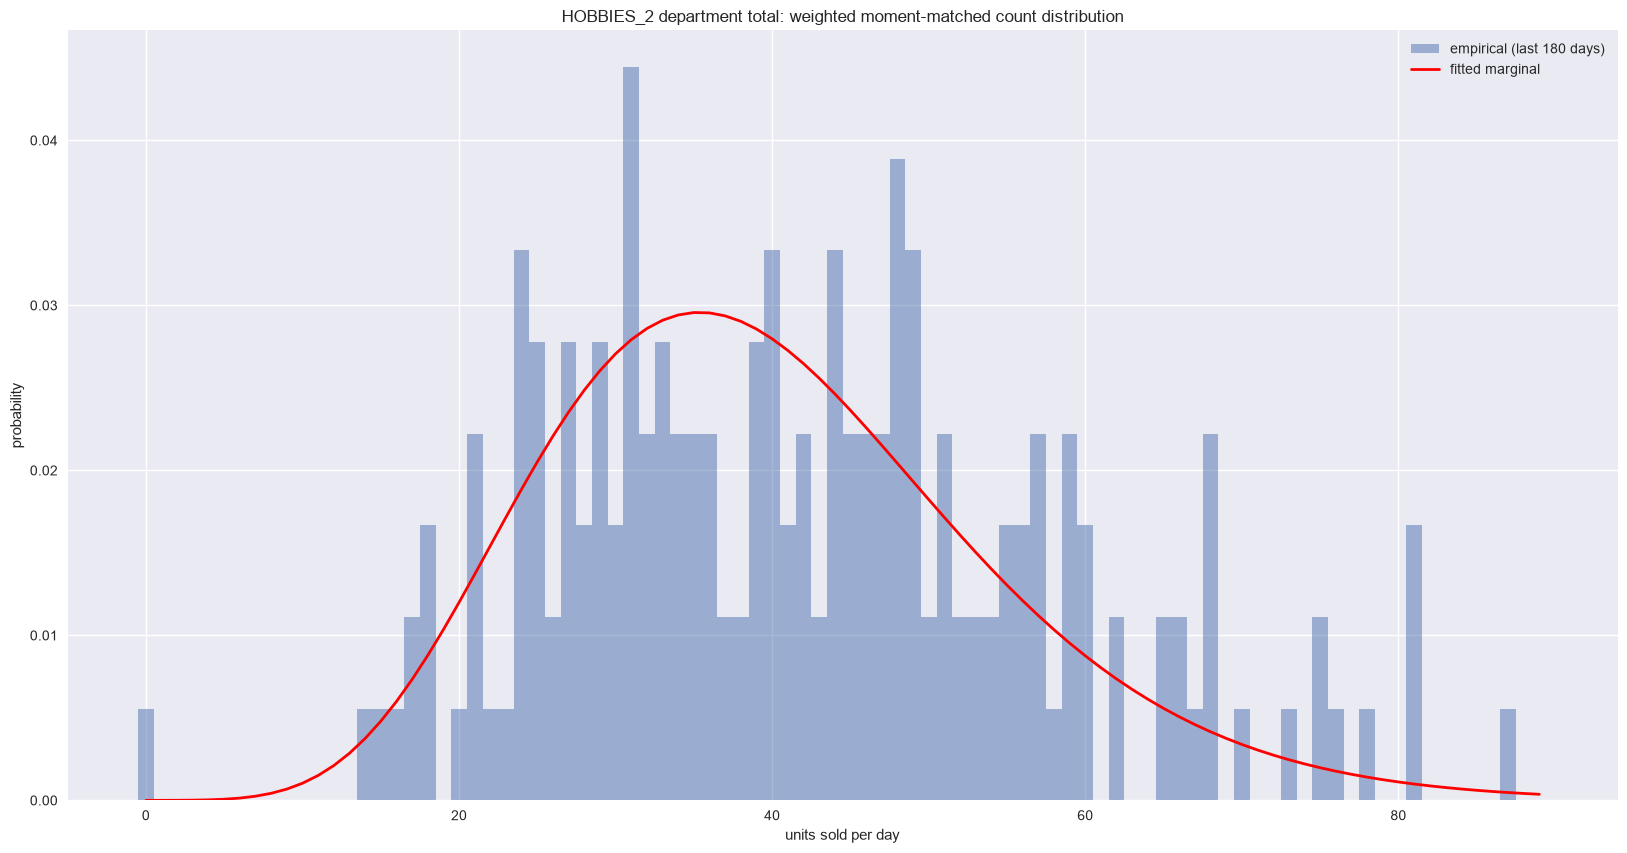

distribution: nbinom
fitted mean : 39.9   fitted var: 198.5


In [13]:
h2_sum = train[items_by_dept['HOBBIES_2']].sum(axis=1)
dist_h2 = fit_count_marginal(h2_sum.to_numpy(), w_demo)

k = np.arange(0, 90)
plt.hist(h2_sum.tail(180), bins=np.arange(0, 91) - 0.5, density=True,
         alpha=0.5, label='empirical (last 180 days)')
plt.plot(k, dist_h2.pmf(k), color='red', linewidth=2, label='fitted marginal')
plt.title('HOBBIES_2 department total: weighted moment-matched count distribution')
plt.xlabel('units sold per day')
plt.ylabel('probability')
plt.legend()
plt.show()

print('distribution:', dist_h2.dist.name)
print('fitted mean :', round(float(dist_h2.mean()), 1), '  fitted var:', round(float(dist_h2.var()), 1))

A demonstration of `fit_count_marginal` on a real series — the daily total of the `HOBBIES_2` department. We fit with the full training history and the decay weights, then compare the fitted probability mass function (red line, plotted via `.pmf(k)` on an integer grid) against a histogram of the most recent 180 days (`density=True` puts the histogram on the probability scale so the two are comparable).

The printout tells us the fitter chose the **negative binomial**: the fitted variance is well above the fitted mean, i.e., the data is overdispersed, exactly as expected for demand counts. The fit is not perfect — no two-parameter distribution will be — but it captures the location and the spread of recent demand, and that is all the top-down sampler will ask of it. Note also how the recency weighting matters: the *full-history* mean of this series is about 29 units/day, yet the fitted mean (≈40) sits at the department's recent level — the last four weeks of training average ≈38 units/day.

## The Plackett copula

A marginal for each child is not enough — the two children of a split are usually *correlated* (hobby items sell together on busy Saturdays). A **copula** is a device that couples two marginal distributions into one joint distribution while adding exactly one thing: the dependence structure. The paper picks the **Plackett copula**, which has a single parameter θ > 0: θ = 1 means independence, θ > 1 positive dependence, θ < 1 negative dependence.

In [14]:
def plackett_cdf(u, v, theta):
    """Plackett copula C(u, v; theta); reduces to u*v at theta = 1 (independence)."""
    u = np.asarray(u, float)
    v = np.asarray(v, float)
    if abs(theta - 1.0) < 1e-9:
        return u * v
    S = 1.0 + (theta - 1.0) * (u + v)
    disc = S ** 2 - 4.0 * u * v * theta * (theta - 1.0)
    return (S - np.sqrt(np.maximum(disc, 0.0))) / (2.0 * (theta - 1.0))


def plackett_spearman(theta):
    """Spearman's rank correlation implied by a Plackett copula with parameter theta."""
    if abs(theta - 1.0) < 1e-9:
        return 0.0
    return (theta + 1.0) / (theta - 1.0) - 2.0 * theta * np.log(theta) / (theta - 1.0) ** 2


def theta_from_spearman(rho):
    """Invert rho(theta) numerically: find the theta whose implied Spearman rho matches."""
    rho = float(np.clip(rho, -0.985, 0.985))
    if abs(rho) < 1e-6:
        return 1.0
    f = lambda log_t: plackett_spearman(np.exp(log_t)) - rho
    return float(np.exp(brentq(f, np.log(1e-6), np.log(1e6))))


for rho in [-0.5, 0.0, 0.3, 0.8]:
    th = theta_from_spearman(rho)
    print(f'rho = {rho:+.2f}  ->  theta = {th:8.4f}  ->  implied rho = {plackett_spearman(th):+.4f}')

rho = -0.50  ->  theta =   0.1955  ->  implied rho = -0.5000
rho = +0.00  ->  theta =   1.0000  ->  implied rho = +0.0000
rho = +0.30  ->  theta =   2.5235  ->  implied rho = +0.3000
rho = +0.80  ->  theta =  24.2588  ->  implied rho = +0.8000


Three short functions and a sanity check. `plackett_cdf` is the copula itself: a function C(u, v) on the unit square that behaves like a joint CDF whose both marginals are uniform. The closed form looks opaque but is just the solution of a quadratic; the two guards handle numerical edge cases (`theta ≈ 1` would divide by zero, so we return the independence copula `u·v` directly, and `np.maximum(disc, 0)` protects the square root from tiny negative values caused by floating-point noise).

The real reason the paper picks Plackett over better-known copulas is `theta_from_spearman`: for this family there is a *closed-form* relationship between θ and **Spearman's rank correlation** ρ, implemented in `plackett_spearman`. Estimating the dependence therefore costs one rank correlation from the data plus one one-dimensional root-finding call (`brentq` on the log of θ, searching θ between 10⁻⁶ and 10⁶) — no likelihood optimization at all. Same design principle as moment matching for the marginals: closed forms wherever possible, because this estimation happens at every node of a large tree.

The round-trip check confirms the inversion is exact: feeding ρ = −0.5, 0, 0.3, 0.8 recovers thetas (≈0.196, 1, 2.52, 24.3) whose implied Spearman correlations match to four decimals.

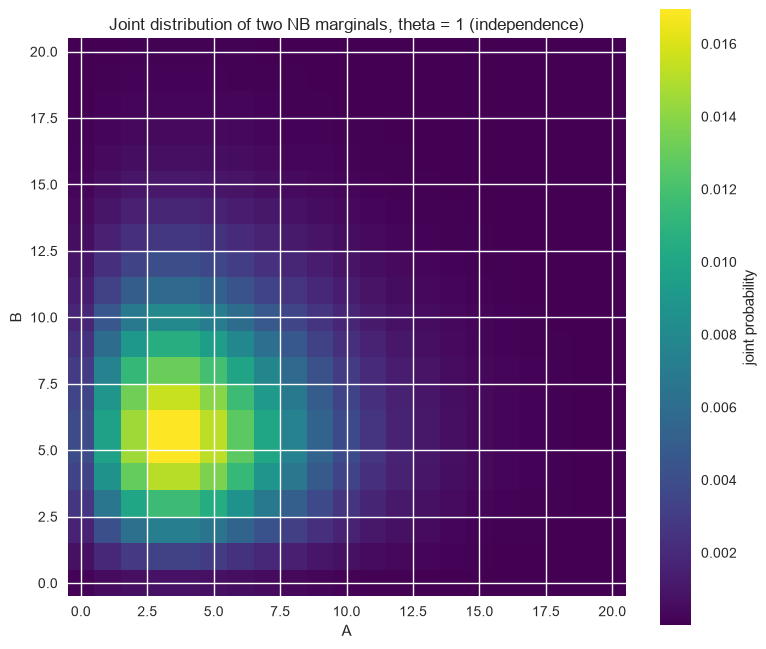

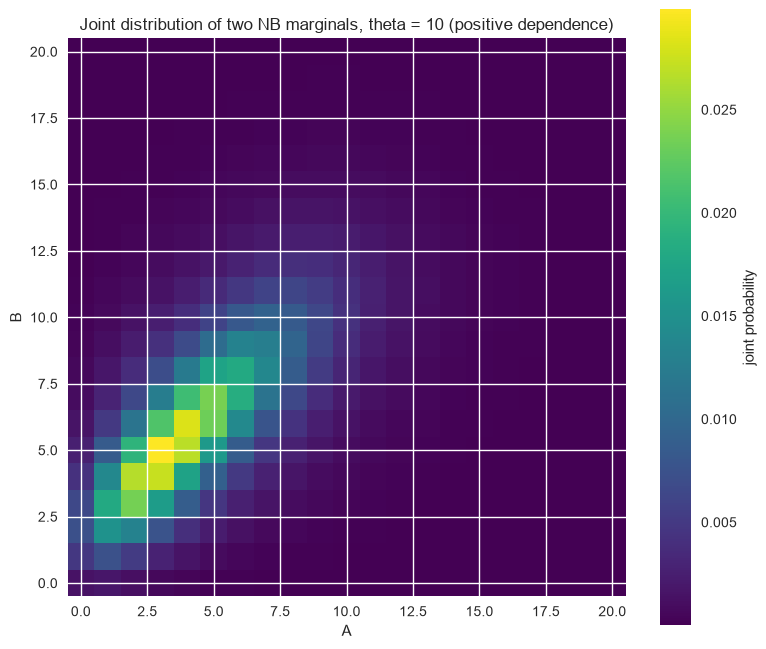

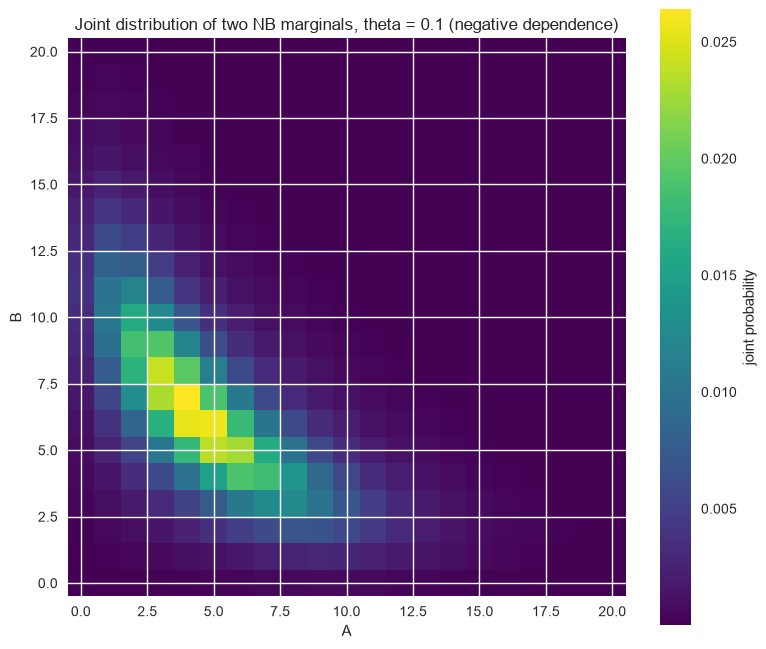

In [15]:
def plackett_joint_pmf(distA, distB, theta, amax, bmax):
    """Joint pmf table P[a, b] for counts, via rectangle probabilities of the copula."""
    a = np.arange(amax + 1)
    b = np.arange(bmax + 1)
    FA, FAm = distA.cdf(a), distA.cdf(a - 1)
    FB, FBm = distB.cdf(b), distB.cdf(b - 1)
    P = (plackett_cdf(FA[:, None], FB[None, :], theta)
         - plackett_cdf(FAm[:, None], FB[None, :], theta)
         - plackett_cdf(FA[:, None], FBm[None, :], theta)
         + plackett_cdf(FAm[:, None], FBm[None, :], theta))
    return np.maximum(P, 0.0)


demo_A = stats.nbinom(5, 0.5)     # mean 5
demo_B = stats.nbinom(10, 0.6)    # mean ~6.7

for theta, label in [(1.0, 'theta = 1 (independence)'),
                     (10.0, 'theta = 10 (positive dependence)'),
                     (0.1, 'theta = 0.1 (negative dependence)')]:
    P = plackett_joint_pmf(demo_A, demo_B, theta, 20, 20)
    plt.figure(figsize=(9, 8))
    plt.imshow(P.T, origin='lower', cmap='viridis')
    plt.colorbar(label='joint probability')
    plt.title(f'Joint distribution of two NB marginals, {label}')
    plt.xlabel('A')
    plt.ylabel('B')
    plt.show()

How do we get from a copula (which lives on continuous uniforms) to a joint distribution of *integer counts*? By **rectangle probabilities**: for discrete variables, the probability of the exact pair (a, b) is the copula measure of the little rectangle between the CDF values at a−1 and a, and at b−1 and b. That is the four-term inclusion–exclusion in `plackett_joint_pmf` — evaluate C at the four corners, add the two "outer" corners, subtract the two "inner" ones. Broadcasting (`FA[:, None]` against `FB[None, :]`) computes the whole table in one vectorized shot.

The three heatmaps reproduce Figure 5 of the paper. All three share the *same* two negative binomial marginals — NB(5, 0.5) and NB(10, 0.6) — and differ only in θ. The first plot (θ = 1) is the independence baseline: probability mass is a simple product bump. In the second plot (θ = 10) the mass stretches along the diagonal — when A is high, B tends to be high. In the third (θ = 0.1) it stretches along the anti-diagonal — the variables trade off. This is exactly the lever the top-down sampler needs: the marginals say how much each child sells on its own, θ says whether they boom and bust together.

## Splitting a total: sampling under the constraint a + b = z

Now the heart of the paper. Classical top-down (m04 again) splits a total forecast z with a fixed historical proportion: `A` always gets, say, 94% of z. That collapses all the uncertainty about *how* the split happens. The probabilistic version instead asks: given the estimated joint distribution of the children, what does that joint distribution look like *conditioned on the children summing to z*? — and then samples the split from it.

In [16]:
def split_weights(z, distA, distB, theta):
    """Unnormalized probabilities w_j = P(A = j, B = z - j) for j = 0..z."""
    j = np.arange(z + 1)
    FA, FAm = distA.cdf(j), distA.cdf(j - 1)
    FB, FBm = distB.cdf(z - j), distB.cdf(z - j - 1)
    w = (plackett_cdf(FA, FB, theta)
         - plackett_cdf(FAm, FB, theta)
         - plackett_cdf(FA, FBm, theta)
         + plackett_cdf(FAm, FBm, theta))
    return np.maximum(w, 0.0)


def sample_splits(totals, distA, distB, theta, rng):
    """For each integer total z_i, draw a_i from P(A | A + B = z_i). Batched over unique totals."""
    totals = np.asarray(totals, dtype=int)
    a = np.zeros_like(totals)
    muA, muB = distA.mean(), distB.mean()
    p_fallback = muA / max(muA + muB, 1e-12)
    for z in np.unique(totals):
        idx = np.where(totals == z)[0]
        if z == 0:
            continue                      # nothing to split
        w = split_weights(int(z), distA, distB, theta)
        s = w.sum()
        if s < 1e-300:                    # z is far outside the fitted joint: proportional fallback
            a[idx] = rng.binomial(int(z), p_fallback, size=len(idx))
            continue
        a[idx] = rng.choice(z + 1, size=len(idx), p=w / s)
    return a

`split_weights` enumerates every feasible split of an integer total z: the pairs (0, z), (1, z−1), …, (z, 0). For each candidate `j` it evaluates the joint pmf at (j, z−j) using the same rectangle-probability trick as before — this time along the anti-diagonal of the joint table. Normalizing these weights gives the exact conditional distribution of A given A + B = z under the fitted joint. That distribution is the *probabilistic counterpart of a historical proportion*: its mean sits near the historical share, but it has spread, and its spread reflects both marginals and θ.

`sample_splits` turns the weights into draws, with two efficiency/robustness devices lifted straight from the paper. First, **batching over unique totals**: our totals arrive as thousands of samples (500 paths × 28 horizons), but they are small integers taking few distinct values, so we compute the weight vector once per distinct z and draw all samples that share it in one `rng.choice` call. Second, a **fallback** for totals so far outside the fitted joint that every weight underflows to zero (a huge z when the marginals expect single digits): we then split proportionally to the marginal means with a binomial draw, which keeps the algorithm total-preserving no matter what the upper level sends down. A total of zero needs no work at all — both children get zero, which is one reason this method is fast on intermittent data.

Spearman rho = 0.575  ->  theta = 6.97


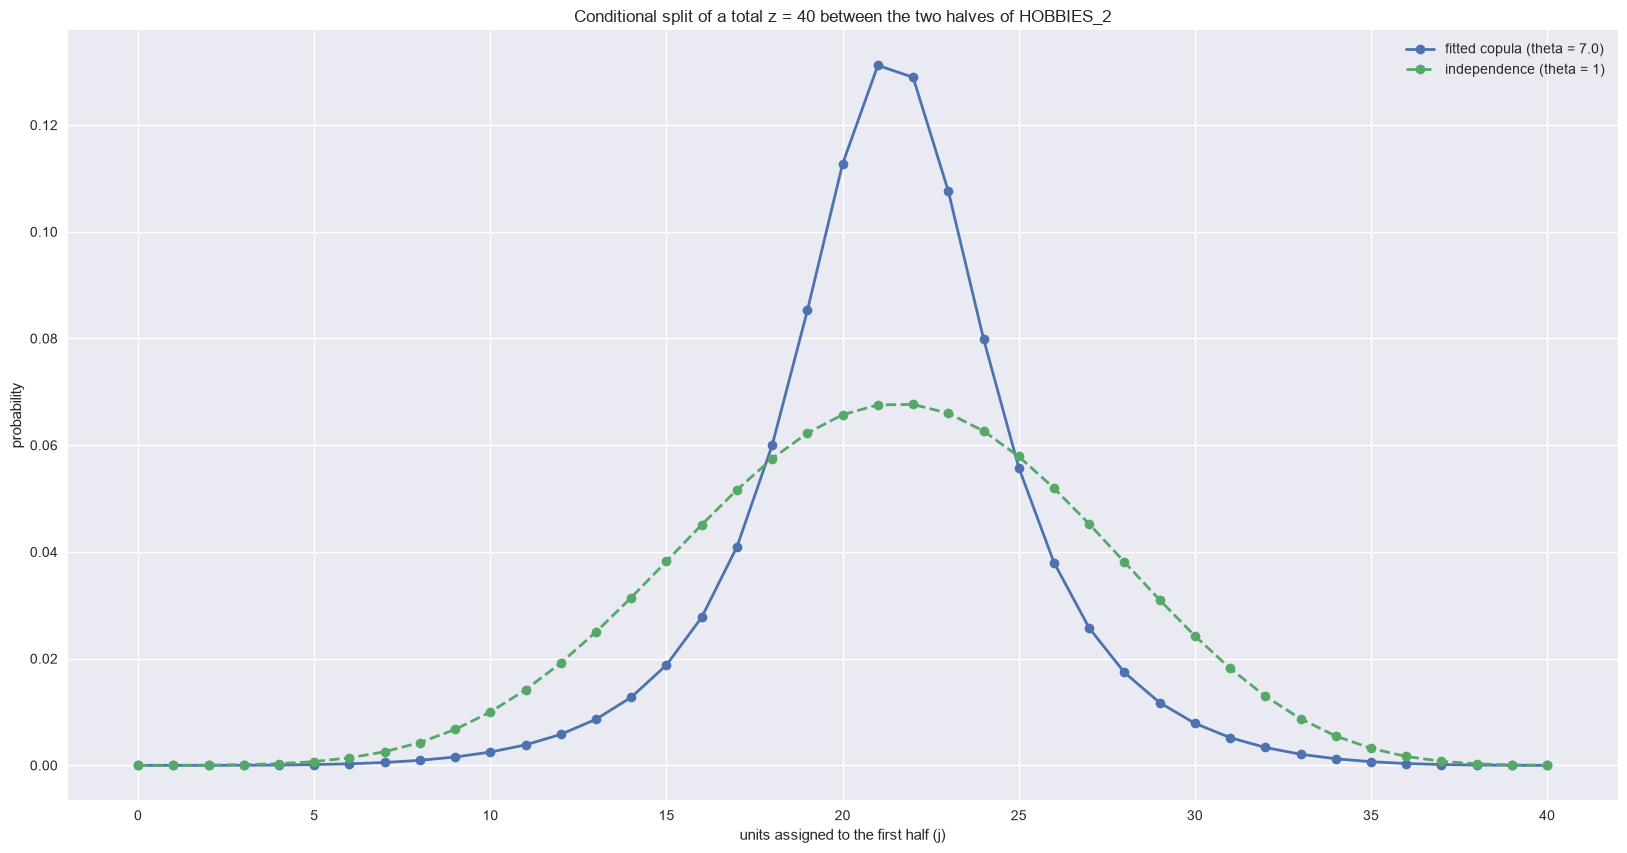

In [17]:
h2_items = items_by_dept['HOBBIES_2']
mid = len(h2_items) // 2
sL = train[h2_items[:mid]].sum(axis=1).to_numpy()
sR = train[h2_items[mid:]].sum(axis=1).to_numpy()

dist_L = fit_count_marginal(sL, w_demo)
dist_R = fit_count_marginal(sR, w_demo)
rho_LR = stats.spearmanr(sL, sR).statistic
theta_LR = theta_from_spearman(rho_LR)
print(f'Spearman rho = {rho_LR:.3f}  ->  theta = {theta_LR:.2f}')

Z_DEMO = 40
j = np.arange(Z_DEMO + 1)
w_dep = split_weights(Z_DEMO, dist_L, dist_R, theta_LR)
w_ind = split_weights(Z_DEMO, dist_L, dist_R, 1.0)

plt.plot(j, w_dep / w_dep.sum(), linewidth=2, marker='o', label=f'fitted copula (theta = {theta_LR:.1f})')
plt.plot(j, w_ind / w_ind.sum(), linewidth=2, marker='o', linestyle='--',
         label='independence (theta = 1)')
plt.title(f'Conditional split of a total z = {Z_DEMO} between the two halves of HOBBIES_2')
plt.xlabel('units assigned to the first half (j)')
plt.ylabel('probability')
plt.legend()
plt.show()

A demonstration on real data: we split the `HOBBIES_2` department into its two halves (74 and 75 items), fit a marginal to each half's daily total, and estimate the dependence. The rank correlation between the halves is strongly positive (ρ ≈ 0.58, θ ≈ 7) — busy days are busy for everyone.

The figure shows the conditional split distribution for a total of z = 40 units, under the fitted copula and under forced independence. Both are centred near the historical share of the first half, but the **fitted copula produces a visibly tighter split distribution**. The intuition: with positive dependence, a given total is most plausibly explained by both halves being proportionally busy, so extreme splits ("half one sold everything") lose probability. Classical top-down would put *all* the mass on a single j — a vertical spike at the historical proportion. The probabilistic version keeps the split honest about its own uncertainty, and the copula fine-tunes how much uncertainty that is.

# The e2eTD pipeline

With the ingredients in place, we assemble the five steps: select the uppers, forecast them, reconcile, sample top-down, aggregate.

## Step I: choose the upper sub-hierarchy

In [18]:
uppers_train = pd.DataFrame({'TOTAL': train.sum(axis=1),
                             **{d: train[items_by_dept[d]].sum(axis=1) for d in depts}})
uppers_test = pd.DataFrame({'TOTAL': test.sum(axis=1),
                            **{d: test[items_by_dept[d]].sum(axis=1) for d in depts}})

n_total_series = 1 + len(depts) + len(bottom.columns)
print(uppers_train.tail(3))
print(f'directly forecast: {uppers_train.shape[1]} of {n_total_series} series '
      f'({100 * uppers_train.shape[1] / n_total_series:.2f}% of the hierarchy)')

            TOTAL  HOBBIES_1  HOBBIES_2
date                                   
2016-04-22    527        471         56
2016-04-23    670        621         49
2016-04-24    714        641         73
directly forecast: 3 of 568 series (0.53% of the hierarchy)


Step I of e2eTD is a *selection*: pick a small set of upper series that (a) are smooth enough to forecast well and (b) **cover** every bottom series — each item must be a descendant of at least one selected series. In our three-level slice the natural choice is the total plus the two departments: 3 series out of 568, or ~0.5% of the hierarchy — the same order as the paper's 0.36% on M5 and 0.28% on Favorita. Everything below the department level will never see a forecasting model; it will be handled entirely by the top-down sampler.

We build the selected series for both the training and the test window by summing item columns (`sum(axis=1)` on the appropriate column subsets). The departments form the *lowest selected level* — the level from which the top-down sampling will start.

## Step II: forecast the selected uppers with ETS

In [19]:
def fit_ets(y):
    """Fit ETS with additive error and weekly seasonality; pick the spec by AICc."""
    best, best_aicc = None, np.inf
    for trend, damped in [(None, False), ('add', False), ('add', True)]:
        for seasonal in [None, 'add']:
            model = ETSModel(y.astype(float), error='add',
                             trend=trend, damped_trend=damped,
                             seasonal=seasonal, seasonal_periods=7 if seasonal else None)
            fit = model.fit(disp=False)
            if fit.aicc < best_aicc:
                best, best_aicc = fit, fit.aicc
    return best

The forecasting model for the uppers is deliberately boring: **exponential smoothing (ETS)** with automatic model selection, the same family the paper uses (their ablation shows ARIMA does about equally well — the choice of upper-level model is not where the magic is). Our small grid tries six specifications: trend absent, additive, or additive-damped, crossed with weekly seasonality absent or additive (`seasonal_periods=7` for daily data). Each candidate is fit by maximum likelihood (`disp=False` just silences the optimizer's progress printout), and we keep the specification with the lowest **AICc** — the small-sample-corrected Akaike criterion, which rewards likelihood but penalizes parameter count, guarding against overfitting the seasonal terms.

We skip the paper's exogenous regressors (SNAP and holiday indicators) to stay minimal — their ablation shows the regressors help on M5, so consider that the first upgrade if you extend this notebook.

In [20]:
t0 = time.time()
ets_fits = {}
for name in uppers_train.columns:
    y = uppers_train[name].copy()
    y.index = pd.date_range(y.index[0], periods=len(y), freq='D')
    ets_fits[name] = fit_ets(y)
    fit = ets_fits[name]
    print(f'{name:10s}  trend={str(fit.model.trend):5s} damped={fit.model.damped_trend!s:5s} '
          f'seasonal={str(fit.model.seasonal):5s}  AICc={fit.aicc:.1f}')
print(f'ETS fitting time: {time.time() - t0:.1f} s')

TOTAL       trend=None  damped=False seasonal=add    AICc=22634.8


HOBBIES_1   trend=add   damped=False seasonal=add    AICc=22553.6


HOBBIES_2   trend=None  damped=False seasonal=add    AICc=14703.5
ETS fitting time: 0.4 s


We loop over the three selected series and fit each one. One small but necessary trick: `ETSModel` wants an index with an explicit frequency, so we replace the index with a `pd.date_range(..., freq='D')` covering the same days (our data is contiguous daily, so this is a relabelling, not a change).

The selection results are sensible: all three series get weekly **additive seasonality**; `HOBBIES_1` — the department with visible growth — also earns an additive trend, while `TOTAL` and `HOBBIES_2` are happy with level plus seasonality. Fitting all three models takes well under a second, which is the scaling story of the whole method: on full M5 the paper fits 154 such models (in parallel) and that remains the *dominant* cost of the entire pipeline, ~70% of its five minutes.

In [21]:
ets_sims, ets_mu, ets_var = {}, {}, {}
for name, fit in ets_fits.items():
    sims = fit.simulate(nsimulations=CFG.HORIZON, repetitions=2000,
                        anchor='end', random_state=CFG.SEED)
    ets_sims[name] = sims
    ets_mu[name] = sims.mean(axis=1).to_numpy()
    ets_var[name] = sims.var(axis=1).to_numpy()
    print(f'{name:10s}  mean forecast h=1: {ets_mu[name][0]:6.1f}   h=28: {ets_mu[name][-1]:6.1f}')

TOTAL       mean forecast h=1:  517.3   h=28:  608.2
HOBBIES_1   mean forecast h=1:  482.7   h=28:  559.9
HOBBIES_2   mean forecast h=1:   40.1   h=28:   52.3


ETS is a state-space model, so it gives us more than point forecasts: `fit.simulate(...)` rolls the fitted state equations forward `nsimulations=28` days, injecting fresh innovation noise, and does so `repetitions=2000` times — 2,000 plausible futures per series. `anchor='end'` starts the simulation from the last training state, and `random_state=CFG.SEED` keeps it reproducible.

From the simulation fan we extract, per horizon, the predictive **mean** and **variance** (`axis=1` averages across repetitions). These per-horizon Gaussian summaries are all that the next step needs. Notice the means drift upward from h=1 to h=28 — the fitted trend and seasonality at work — and that the predictive variance grows with horizon, which will matter later: it is precisely the feature that static baselines lack.

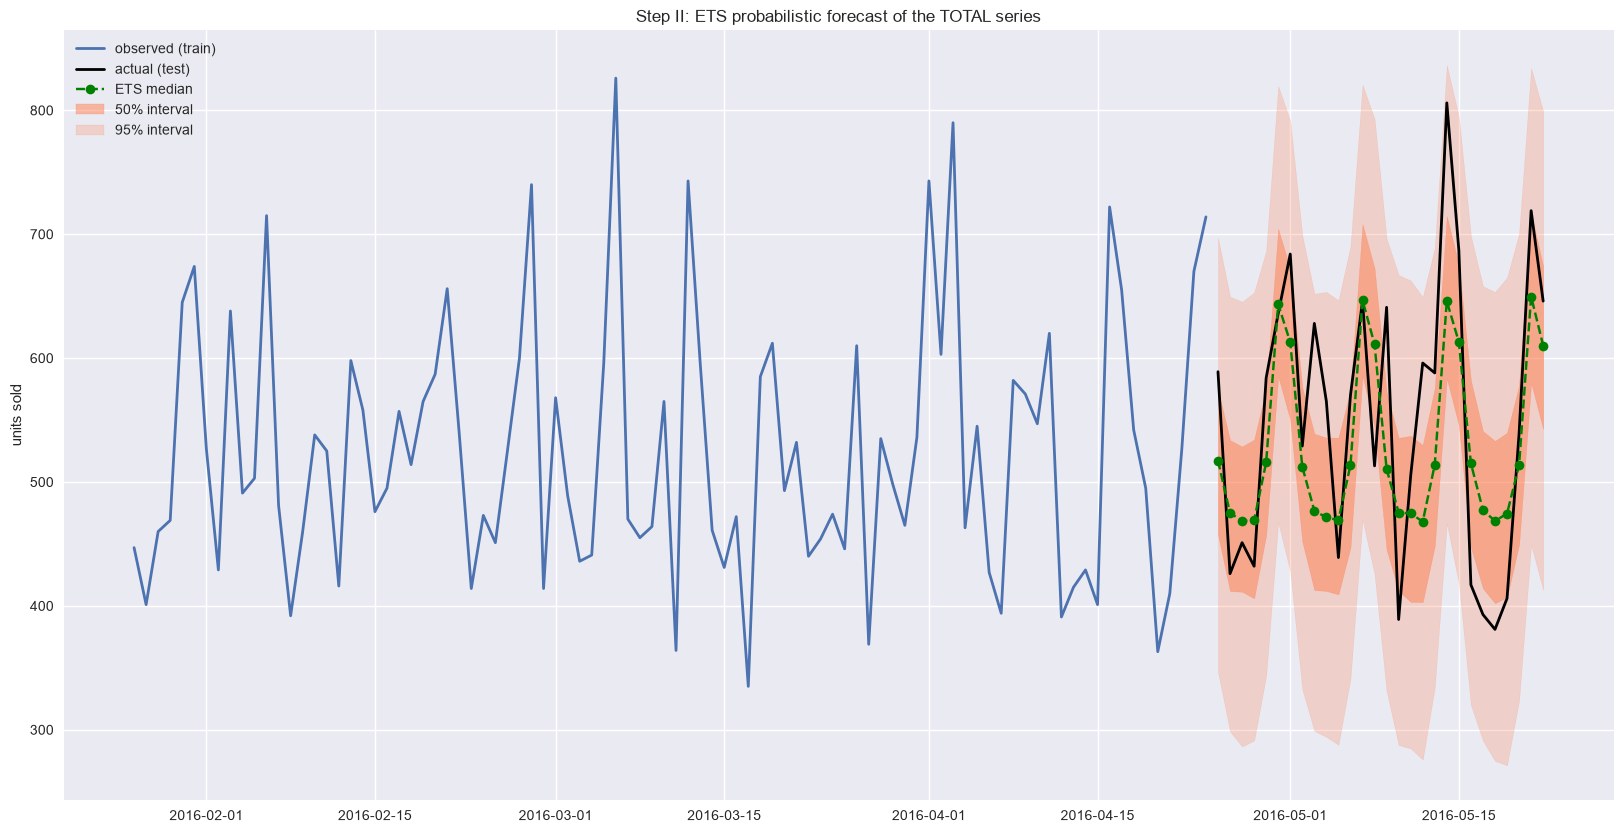

In [22]:
name = 'TOTAL'
q_lo95, q_lo50, q_med, q_hi50, q_hi95 = [ets_sims[name].quantile(q, axis=1)
                                         for q in [0.025, 0.25, 0.5, 0.75, 0.975]]
fdates = test.index

plt.plot(train.index[-90:], uppers_train[name].tail(90), linewidth=2, label='observed (train)')
plt.plot(fdates, uppers_test[name], color='black', linewidth=2, label='actual (test)')
plt.plot(fdates, q_med, color='green', linestyle='--', marker='o', label='ETS median')
plt.fill_between(fdates, q_lo50, q_hi50, color='coral', alpha=0.5, label='50% interval')
plt.fill_between(fdates, q_lo95, q_hi95, color='coral', alpha=0.25, label='95% interval')
plt.title('Step II: ETS probabilistic forecast of the TOTAL series')
plt.ylabel('units sold')
plt.legend()
plt.show()

The fan chart for the total series: the last 90 training days, the median simulated path (green dashed), and the 50%/95% bands computed as quantiles across the 2,000 simulations. The weekly rhythm continues into the forecast, the bands widen slightly with horizon, and the held-out actuals (black) spend most of their time inside the 50% band. This is the *only* kind of forecast the method ever produces directly — everything below will be derived from these upper-level fans by reconciliation and disaggregation.

## Step III: reconcile the uppers, sample the lowest selected level

Our three upper forecasts were fit independently, so they disagree: the forecast for `TOTAL` is not exactly the sum of the two department forecasts. Traditional top-down would just ignore two of the three forecasts. e2eTD instead **reconciles** them — treating the three per-horizon forecasts as independent Gaussians and conditioning that joint Gaussian on the constraint `TOTAL − HOBBIES_1 − HOBBIES_2 = 0`. Conditioning a multivariate normal on a linear constraint has a closed form, the same conditioning formula we have met in Kalman-filter land:

`mu* = mu − Σc (cᵀΣc)⁻¹ (cᵀmu)`,  `Σ* = Σ − Σc (cᵀΣc)⁻¹ cᵀΣ`,

where `c = (1, −1, −1)` encodes the constraint. Every series moves toward agreement by an amount proportional to its own variance — the least confident forecast concedes the most.

In [23]:
rng = np.random.default_rng(CFG.SEED)
names = ['TOTAL'] + depts
c = np.array([1.0, -1.0, -1.0])

recon_samples = np.zeros((CFG.HORIZON, CFG.N_SAMPLES, len(depts)))  # joint dept samples
recon_mu = np.zeros((CFG.HORIZON, len(names)))
for h in range(CFG.HORIZON):
    mu = np.array([ets_mu[n][h] for n in names])
    Sigma = np.diag([ets_var[n][h] for n in names])
    k = Sigma @ c / (c @ Sigma @ c)
    mu_r = mu - k * (c @ mu)
    Sigma_r = Sigma - np.outer(k, c @ Sigma)
    Sigma_r = (Sigma_r + Sigma_r.T) / 2
    recon_mu[h] = mu_r
    draws = rng.multivariate_normal(mu_r[1:], Sigma_r[1:, 1:], size=CFG.N_SAMPLES)
    recon_samples[h] = np.maximum(np.rint(draws), 0)

print('base       means, h=1:', np.array([ets_mu[n][0] for n in names]).round(1))
print('reconciled means, h=1:', recon_mu[0].round(1))
print('constraint check (mu_Z - mu_A - mu_B):', round(float(recon_mu[0] @ c), 6))

base       means, h=1: [517.3 482.7  40.1]
reconciled means, h=1: [520.1 480.   40. ]
constraint check (mu_Z - mu_A - mu_B): -0.0


The loop applies the conditioning formula horizon by horizon. `k = Σc / (cᵀΣc)` is the gain vector; subtracting `k · (cᵀmu)` removes the *coherence error* `cᵀmu` (how far the base means are from adding up) in proportion to each series' variance. The symmetrization line is numerical hygiene before sampling.

From the reconciled Gaussian we keep only the **lowest selected level** — the two departments (`mu_r[1:]`, `Sigma_r[1:, 1:]`) — and draw `N_SAMPLES` *joint* samples per horizon with `rng.multivariate_normal`. Joint is the operative word: the reconciled covariance now couples the departments, so a sample where `HOBBIES_1` booms tends to come with an appropriate `HOBBIES_2`. Finally `np.rint` rounds to integers and `np.maximum(..., 0)` clips negatives, because these samples are about to become count totals that we split among items (the paper does exactly the same rounding).

The printout shows the mechanics: at h=1 the base means (517.3 vs 482.7 + 40.1 = 522.8) disagree by about 5.5 units; reconciliation lands on 520.1 = 480.0 + 40.0, and the constraint check is zero to machine precision.

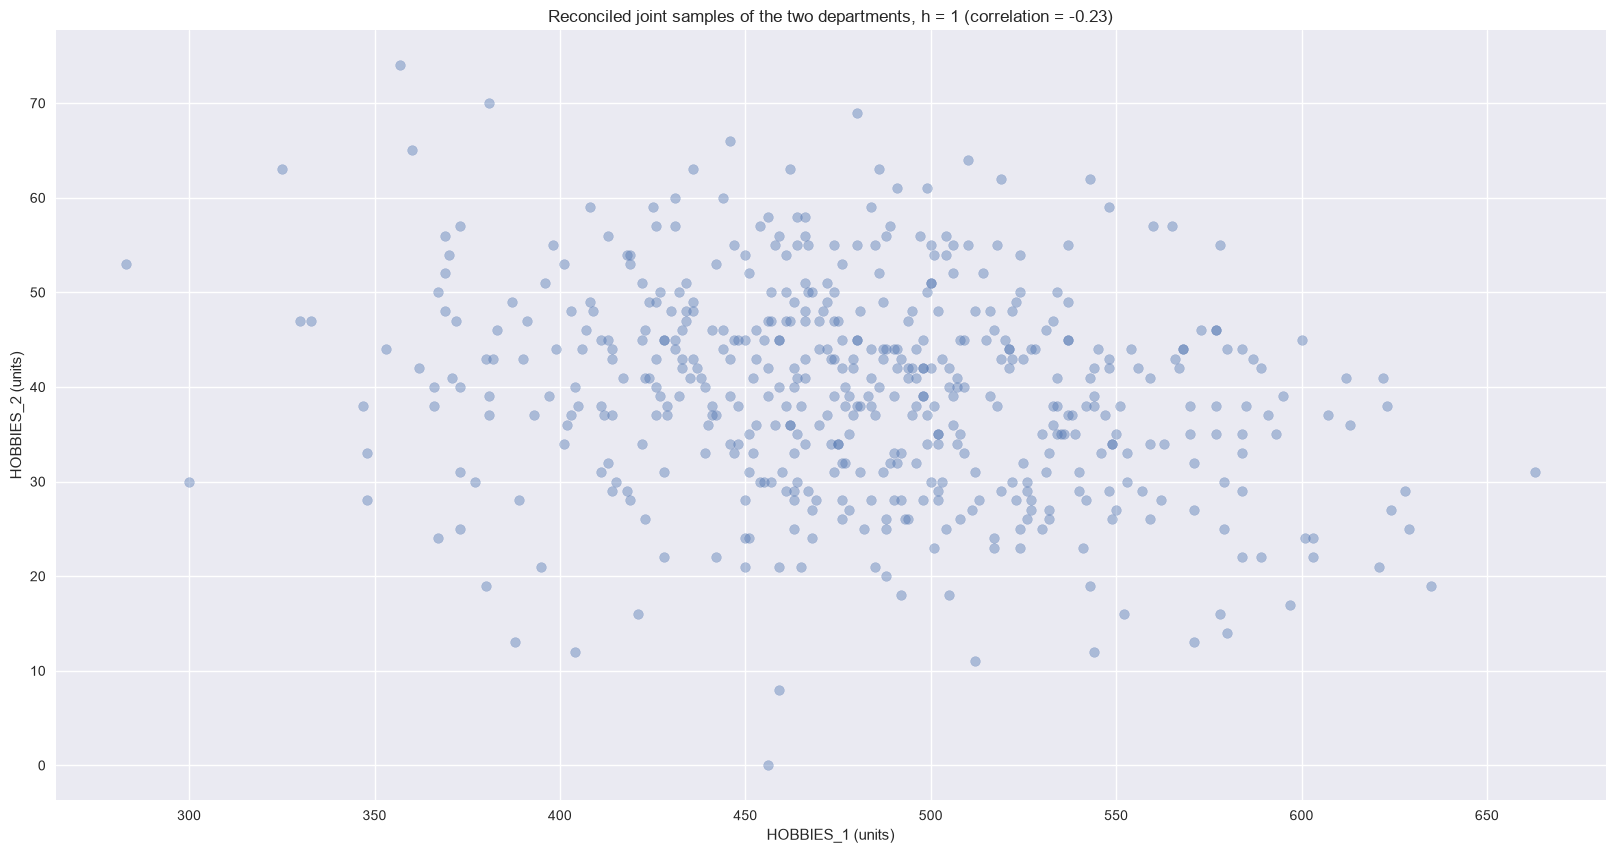

In [24]:
dept_corr = np.corrcoef(recon_samples[0, :, 0], recon_samples[0, :, 1])[0, 1]

plt.scatter(recon_samples[0, :, 0], recon_samples[0, :, 1], alpha=0.4)
plt.title(f'Reconciled joint samples of the two departments, h = 1 '
          f'(correlation = {dept_corr:.2f})')
plt.xlabel('HOBBIES_1 (units)')
plt.ylabel('HOBBIES_2 (units)')
plt.show()

A scatter of the 500 joint department samples at horizon 1. The mild negative correlation is not a bug — it is what conditioning on a constraint does. Before reconciliation the three forecasts were independent; once we force them to satisfy `TOTAL = H1 + H2`, knowing the total leaves the two departments competing for the same units, which induces a slight trade-off between them. Each dot in this cloud is one scenario for "how much does each department sell on April 25, 2016", and each will now be pushed down to the 565 items.

## Step IV: probabilistic top-down sampling

One department has up to 416 items — we cannot enumerate splits of a total among 416 children directly. The paper's solution is **recursive binary splitting** (their Figure 4): split the item list in half, split the sampled total between the two halves with the bivariate machinery we built, then recurse into each half with its share, all the way down to single items. Each internal node needs two marginals and one θ — all estimated in-sample with our closed-form estimators.

In [25]:
def fit_pair(sA, sB, w):
    """Marginals + Plackett theta for a pair of (aggregated) training series."""
    distA = fit_count_marginal(sA, w)
    distB = fit_count_marginal(sB, w)
    if np.std(sA) < 1e-12 or np.std(sB) < 1e-12:
        theta = 1.0                    # a constant series has no rank correlation
    else:
        rho = stats.spearmanr(sA, sB).statistic
        theta = theta_from_spearman(0.0 if np.isnan(rho) else rho)
    return distA, distB, theta


def topdown_sample(items, totals, train_arr, col_idx, w, rng, out, theta_override=None):
    """Recursively split `totals` across `items`; write per-item samples into `out`."""
    if len(items) == 1:
        out[:, col_idx[items[0]]] = totals
        return
    mid = len(items) // 2
    L, R = items[:mid], items[mid:]
    sL = train_arr[:, [col_idx[i] for i in L]].sum(axis=1)
    sR = train_arr[:, [col_idx[i] for i in R]].sum(axis=1)
    distA, distB, theta = fit_pair(sL, sR, w)
    if theta_override is not None:
        theta = theta_override
    a = sample_splits(totals, distA, distB, theta, rng)
    topdown_sample(L, a, train_arr, col_idx, w, rng, out, theta_override)
    topdown_sample(R, totals - a, train_arr, col_idx, w, rng, out, theta_override)

`fit_pair` packages the estimation at one tree node: two moment-matched marginals plus a Spearman-inverted θ. (We estimate ρ on the unweighted full history for simplicity; the paper applies its recency weighting here too.) The guard for constant series matters in practice — some item groups never sell in parts of the history, and `spearmanr` would return NaN.

`topdown_sample` is the whole algorithm in fifteen lines. At a leaf (one item), the incoming totals *are* that item's samples — write them into the output array. Otherwise: split the item list at the midpoint, build the two halves' historical aggregate series by summing training columns, fit the pair, sample the split of every incoming total with `sample_splits`, and recurse — the first half receives `a`, the second half `totals − a`. By construction, at every level of the recursion the children's samples sum *exactly* to the parent's, sample by sample; coherence is not imposed afterwards, it is preserved at each step. The `theta_override` argument lets us rerun the identical pipeline with θ forced to 1 — the paper's "independence copula" ablation — which we will use later.

Depth of the recursion is log₂(416) ≈ 9, and the number of internal nodes is one less than the number of items, so the whole department costs about 415 pair-estimations — each a couple of weighted moments and one root-find. This is why e2eTD scales.

In [26]:
t0 = time.time()
w_decay = decay_weights(len(train))
train_arr = train.to_numpy()
col_idx = {c_: i for i, c_ in enumerate(train.columns)}


def run_e2etd(theta_override=None, seed=123):
    rng_td = np.random.default_rng(seed)
    out = np.zeros((CFG.HORIZON * CFG.N_SAMPLES, len(bottom.columns)), dtype=int)
    for di, d in enumerate(depts):
        totals = recon_samples[:, :, di].reshape(-1).astype(int)  # pool all horizons
        topdown_sample(items_by_dept[d], totals, train_arr, col_idx, w_decay, rng_td, out,
                       theta_override)
    return out.reshape(CFG.HORIZON, CFG.N_SAMPLES, -1)


bottom_e2etd = run_e2etd()
print(f'top-down sampling: {bottom_e2etd.shape[0] * bottom_e2etd.shape[1]:,} joint scenarios '
      f'x {bottom_e2etd.shape[2]} items in {time.time() - t0:.1f} s')

top-down sampling: 14,000 joint scenarios x 565 items in 2.8 s


`run_e2etd` drives the sampler once per department, taking care — as the paper stresses — **not to reshuffle the sample index**: sample *i* of `HOBBIES_1` and sample *i* of `HOBBIES_2` came from the same reconciled joint draw, and keeping them aligned is what preserves the cross-department dependence in the final scenarios.

Two of the paper's computational strategies appear here. The 28 horizons are **pooled into one pass**: the split distributions are estimated in-sample and do not depend on the horizon, so we flatten the (28, 500) grid of department totals into one vector of 14,000 and run the recursion once. And inside `sample_splits`, the **unique-totals batching** means those 14,000 totals collapse to a few dozen distinct integers per node. The result: 14,000 coherent scenarios across 565 items in roughly three seconds of pure Python/NumPy — the paper's optimized R/C++ implementation does the full 30,490-item M5 in about a minute for this step.

## Step V: aggregate and check coherence

In [27]:
dept_from_bottom = np.stack(
    [bottom_e2etd[:, :, [col_idx[i] for i in items_by_dept[d]]].sum(axis=2) for d in depts],
    axis=2)
total_from_bottom = bottom_e2etd.sum(axis=2)

print('bottom sums == reconciled dept samples:',
      bool(np.all(dept_from_bottom == recon_samples.astype(int))))
print('total sample = dept1 + dept2 by construction; e.g. scenario 0, h=1:',
      total_from_bottom[0, 0], '=', dept_from_bottom[0, 0, 0], '+', dept_from_bottom[0, 0, 1])

bottom sums == reconciled dept samples: True
total sample = dept1 + dept2 by construction; e.g. scenario 0, h=1: 490 = 461 + 29


Step V is almost anticlimactic, and that is the point. To get forecasts at *any* aggregation level we simply **sum the joint bottom samples** — no further modelling, no adjustment. The check confirms probabilistic coherence exactly: summing each scenario's items within a department reproduces, integer for integer, the reconciled department sample that scenario started from. Every one of the 14,000 scenarios is a fully consistent miniature world: its items sum to its departments, its departments sum to its total. Quantiles, intervals, or risk measures read off these scenarios can therefore never contradict each other across levels — which was the whole brief.

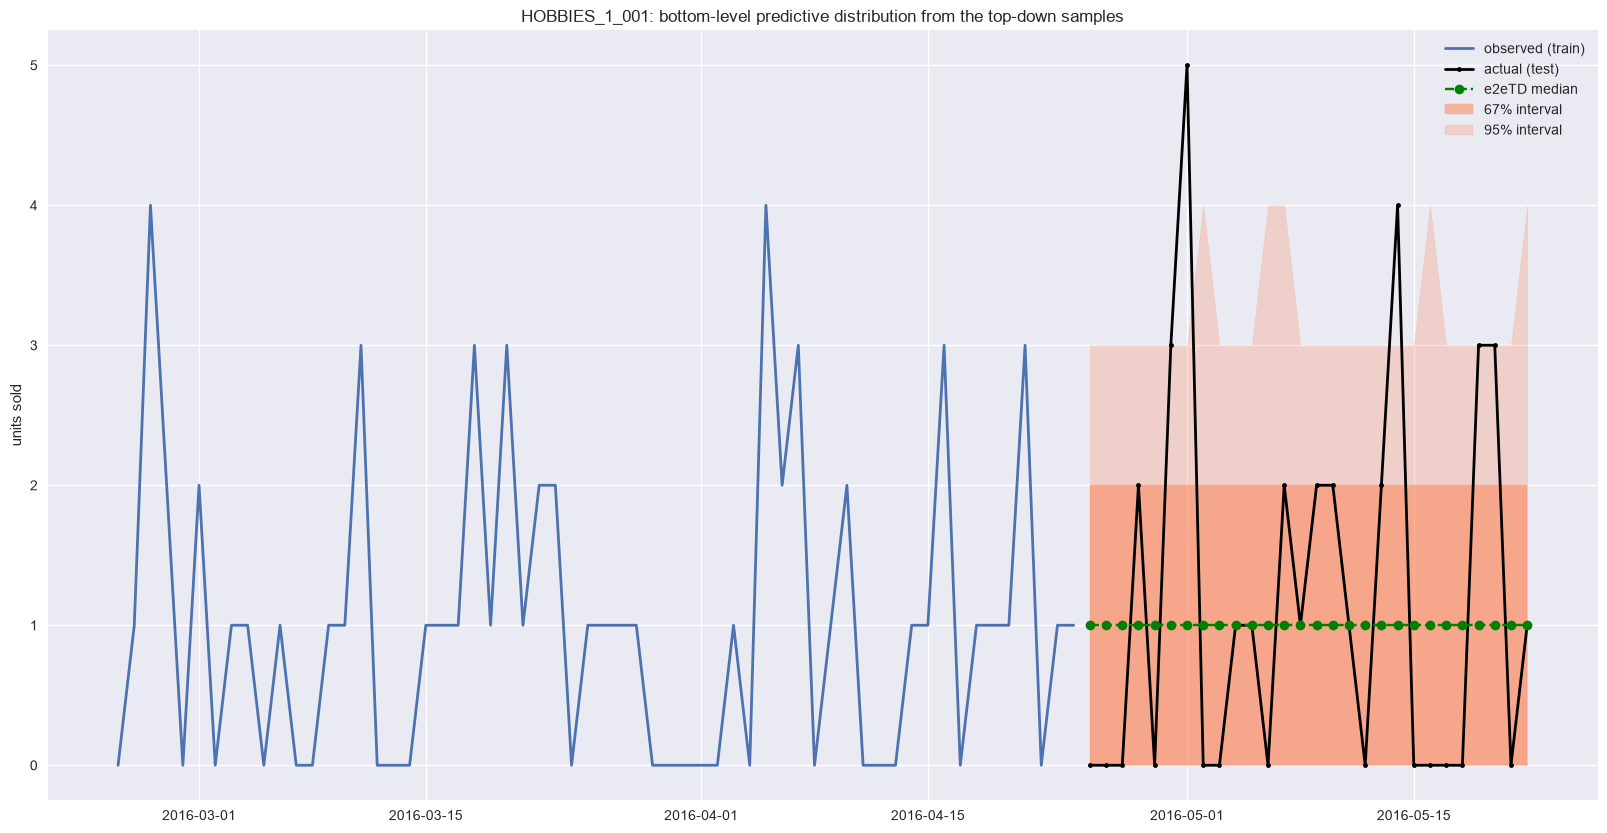

predicted P(zero sales) at h=1: 0.36    historical share of zeros: 0.39


In [28]:
item = 'HOBBIES_1_001'
s_item = bottom_e2etd[:, :, col_idx[item]]
q05, q165, q50, q835, q975 = [np.quantile(s_item, q, axis=1)
                              for q in [0.025, 0.165, 0.5, 0.835, 0.975]]

plt.plot(train.index[-60:], train[item].tail(60), linewidth=2, label='observed (train)')
plt.plot(test.index, test[item], color='black', linewidth=2, marker='.', label='actual (test)')
plt.plot(test.index, q50, color='green', linestyle='--', marker='o', label='e2eTD median')
plt.fill_between(test.index, q165, q835, color='coral', alpha=0.5, label='67% interval')
plt.fill_between(test.index, q05, q975, color='coral', alpha=0.25, label='95% interval')
plt.title(f'{item}: bottom-level predictive distribution from the top-down samples')
plt.ylabel('units sold')
plt.legend()
plt.show()

print('predicted P(zero sales) at h=1:', round(float((s_item[0] == 0).mean()), 2),
      '   historical share of zeros:', round(float((train[item] == 0).tail(90).mean()), 2))

What does a *derived* bottom-level forecast look like? For our intermittent item the median forecast (green) sits flat at one unit, with the 67% band spanning 0–2 units and the 95% band reaching 3–4. A flat low median with wide asymmetric count intervals is exactly the right shape for intermittent demand — the information is in the tails, not the centre, which is why the M5 competition scores nine quantiles rather than a point forecast.

Look at the printout for the calibration detail: the predicted probability of a zero-sales day is 0.36, closely tracking the item's zero share over the last 90 training days (0.39) — and well below its *full-history* zero share of 0.78, because this item has visibly sped up and the recency-weighted marginals in the sampler know it. Note what happened here: **we never fit any model to this item**. Its entire predictive distribution — intermittency included — emerged from repeatedly splitting department-level scenarios through the estimated joint distributions. Intermittency arises naturally in the top-down sampling, as the paper puts it.

# Baselines and evaluation

Is any of this machinery worth it? We score e2eTD against the strongest cheap alternatives, using the M5 Uncertainty competition's metric on all three levels of our hierarchy:

- **empD** — the empirical distribution: use the 1,913 historical days as scenarios, same forecast for every horizon. Coherent by construction (each historical day really happened), and the Kernel benchmark of the M5 competition.
- **S-empD** — the seasonal variant: for each test day, only historical days with the same weekday count. Captures the weekly cycle.
- **TD-indep (Long-style)** — classical top-down as a probabilistic method: reconciled department *point* forecasts, split by fixed historical proportions, an independent negative binomial per item. This is the closest published competitor (Long et al. 2025) and the natural "old-school" reference.
- **e2eTD-indep** — the ablation: our pipeline with every copula forced to independence (θ = 1).

In [29]:
naive_mae_bottom = np.abs(np.diff(train_arr, axis=0)).mean(axis=0)
naive_mae_upper = np.abs(uppers_train.diff().dropna()).mean(axis=0)

ACTUAL = {'L1 total': uppers_test[['TOTAL']].to_numpy(),
          'L2 dept': uppers_test[depts].to_numpy(),
          'L3 item': test.to_numpy()}
SCALE = {'L1 total': naive_mae_upper[['TOTAL']].to_numpy(),
         'L2 dept': naive_mae_upper[depts].to_numpy(),
         'L3 item': naive_mae_bottom}


def evaluate(get_q):
    """get_q(alpha) -> dict level -> (HORIZON, n_series) quantile array.
    Returns per-level scaled pinball scores and the cumulative-by-horizon curve."""
    level_scores, level_curves = {}, []
    per_level_pl = {k: np.zeros((CFG.HORIZON, ACTUAL[k].shape[1])) for k in ACTUAL}
    for alpha in CFG.QUANTILES:
        qs = get_q(alpha)
        for k in ACTUAL:
            per_level_pl[k] += pinball(ACTUAL[k], qs[k], alpha) / len(CFG.QUANTILES)
    for k in ACTUAL:
        scaled = per_level_pl[k] / SCALE[k]          # (HORIZON, n_series)
        level_scores[k] = float(scaled.mean())
        level_curves.append(scaled.mean(axis=1))
    curve = np.mean(level_curves, axis=0)
    level_scores['Mean'] = float(np.mean([level_scores[k] for k in ACTUAL]))
    return level_scores, np.cumsum(curve) / np.arange(1, CFG.HORIZON + 1)

The evaluation scaffolding, following the competition's **scaled pinball loss**. For each method we need a function `get_q(alpha)` returning, per level, the forecast quantiles as a (28 days × n series) array. `evaluate` averages the pinball loss over the nine quantile levels, then divides each series' loss by its own scale — the in-sample mean absolute error of the one-step naive forecast (`|y_t − y_{t−1}|` averaged over training). The scaling makes losses comparable across series of wildly different volume: an item selling 0.3 units/day and a total selling 500 both end up around 0.1–0.5 on this scale. (In our slice every series has a positive scale, so no exclusions are needed. We use uniform weights across series, as the paper does for Favorita; the dollar-revenue weights of the official M5 score need price data we don't load here.)

Alongside the per-level scores, `evaluate` also returns the **cumulative mean WSPL by horizon** — the running average of the score over horizons 1..h, averaged over levels — which reproduces the paper's Figure 7 diagnostics.

In [30]:
def q_from_samples(bs):
    """Build a get_q function from joint bottom-level samples of shape (H, N, n_items)."""
    tot = bs.sum(axis=2, keepdims=True)
    dept_arr = np.stack([bs[:, :, [col_idx[i] for i in items_by_dept[d]]].sum(axis=2)
                         for d in depts], axis=2)

    def get_q(alpha):
        return {'L1 total': np.quantile(tot, alpha, axis=1),
                'L2 dept': np.quantile(dept_arr, alpha, axis=1),
                'L3 item': np.quantile(bs, alpha, axis=1)}
    return get_q

For any sample-based method, the quantiles at *every* level come from the same joint scenarios: we aggregate the bottom samples up (once), then take empirical quantiles across the sample dimension (`axis=1`) at whatever level we are scoring. This is the practical payoff of coherent joint samples — one set of scenarios serves the entire hierarchy, and no level can disagree with another.

In [31]:
weekday_train = train.index.dayofweek.to_numpy()
weekday_test = test.index.dayofweek.to_numpy()
uppers_train_np = uppers_train.to_numpy()


def q_empD(alpha):
    return {'L1 total': np.tile(np.quantile(uppers_train_np[:, [0]], alpha, axis=0), (CFG.HORIZON, 1)),
            'L2 dept': np.tile(np.quantile(uppers_train_np[:, 1:], alpha, axis=0), (CFG.HORIZON, 1)),
            'L3 item': np.tile(np.quantile(train_arr, alpha, axis=0), (CFG.HORIZON, 1))}


def q_sempD(alpha):
    qt = np.zeros((CFG.HORIZON, 1))
    qd = np.zeros((CFG.HORIZON, len(depts)))
    qb = np.zeros((CFG.HORIZON, train_arr.shape[1]))
    for h in range(CFG.HORIZON):
        m = weekday_train == weekday_test[h]
        qt[h] = np.quantile(uppers_train_np[m, 0], alpha)
        qd[h] = np.quantile(uppers_train_np[m, 1:], alpha, axis=0)
        qb[h] = np.quantile(train_arr[m], alpha, axis=0)
    return {'L1 total': qt, 'L2 dept': qd, 'L3 item': qb}

The two static baselines. `q_empD` treats the training history itself as the predictive distribution: the α-quantile of the past is the forecast for every future day (`np.tile` repeats it across the 28 horizons). It sounds naive, but for intermittent series the literature keeps finding it embarrassingly hard to beat — a series that is 80% zeros with occasional ones is described almost perfectly by its own histogram.

`q_sempD` refines this by conditioning on the weekday: for each test day, quantiles are computed only over historical days with the same day of week (the boolean mask `m`). Retail demand has strong weekly structure — Saturdays are not Tuesdays — so this one-line refinement is a much stronger opponent, especially at upper levels where the weekly cycle dominates. What *neither* baseline can do is react to trend or recent level shifts: their forecast for day 28 equals their forecast for day 1.

In [32]:
def long_samples(seed=7):
    """Classical top-down: reconciled point forecast x historical proportions,
    independent NB/Poisson per item."""
    rng_l = np.random.default_rng(seed)
    bs = np.zeros((CFG.HORIZON, CFG.N_SAMPLES, len(bottom.columns)), dtype=int)
    for di, d in enumerate(depts):
        cols_i = [col_idx[i] for i in items_by_dept[d]]
        props = (train[items_by_dept[d]].sum() / train[items_by_dept[d]].sum().sum()).to_numpy()
        mu = np.outer(recon_mu[:, 1 + di], props)               # (H, n_items in dept)
        var = np.maximum(train[items_by_dept[d]].var().to_numpy(), mu)
        for h in range(CFG.HORIZON):
            m_ = np.maximum(mu[h], 1e-9)
            v_ = np.maximum(var[h], m_)
            is_pois = v_ <= m_ * (1 + 1e-9)
            r = np.where(is_pois, 1.0, m_ ** 2 / np.maximum(v_ - m_, 1e-9))
            p = r / (r + m_)
            pois = rng_l.poisson(np.tile(m_, (CFG.N_SAMPLES, 1)))
            nb = rng_l.negative_binomial(np.tile(r, (CFG.N_SAMPLES, 1)),
                                         np.tile(p, (CFG.N_SAMPLES, 1)))
            bs[h, :, cols_i] = np.where(is_pois, pois, nb).T
    return bs

The Long-style baseline makes every classical choice at the exact points where e2eTD makes a probabilistic one, which is what makes it the right comparison. The department *mean* forecast is disaggregated by **fixed historical proportions** (`props`, each item's share of department sales over the whole training window) — a deterministic split, no split uncertainty. Each item then gets its own negative binomial with that mean and its in-sample variance (floored at the mean so the NB is well-defined; where variance ≤ mean we fall back to Poisson), and — crucially — items are sampled **independently** of each other.

The independence is the built-in flaw worth watching: it produces reasonable *marginal* forecasts per item, but when we sum independent samples to get department or total forecasts, the fluctuations of 416 independent items average out far too much. The aggregate predictive distributions come out too narrow — overconfident — and the pinball loss at the upper levels punishes that. This is precisely the failure mode the paper documents for this method.

In [33]:
bottom_indep = run_e2etd(theta_override=1.0)

results, curves = {}, {}
for label, gq in [('e2eTD', q_from_samples(bottom_e2etd)),
                  ('e2eTD-indep', q_from_samples(bottom_indep)),
                  ('TD-indep (Long)', q_from_samples(long_samples())),
                  ('empD', q_empD),
                  ('S-empD', q_sempD)]:
    results[label], curves[label] = evaluate(gq)

results_df = pd.DataFrame(results).T[['L1 total', 'L2 dept', 'L3 item', 'Mean']]
results_df.round(3)

,L1 total,L2 dept,L3 item,Mean
e2eTD,0.159,0.164,0.312,0.212
e2eTD-indep,0.159,0.164,0.311,0.212
TD-indep (Long),0.165,0.170,0.332,0.222
empD,0.290,0.351,0.339,0.327
S-empD,0.239,0.315,0.338,0.297


We run the ablation (`theta_override=1.0` reruns the identical pipeline with all copulas forced to independence), generate the Long baseline's samples, and score all five methods. The table rows are methods, the columns are the scaled pinball loss per level plus the mean across levels — lower is better.

The story matches the paper's Tables 2–3 remarkably well for such a small slice:

- **e2eTD wins the mean and every level.** Against the static baselines the margin is largest at the top (≈0.16 vs 0.24–0.29 at L1): the total series has trend and evolving level, which ETS tracks and a frozen histogram cannot.
- **S-empD beats empD** everywhere, confirming that weekday structure matters, and both are genuinely competitive at the bottom level (0.34 vs e2eTD's 0.31) — intermittent items really are well described by their own history.
- **TD-indep (Long) is close at the top but loses everywhere**, and its bottom-level gap (0.33 vs 0.31) shows that even per-item marginals benefit from probabilistic splits; its upper levels suffer from the too-narrow independent-sum distributions.
- **e2eTD-indep is a statistical tie with e2eTD.** On M5 the paper found exactly this (−0.6% to +0.4%): the copula's contribution is negligible *on this dataset*, because the exogenous-free ETS + reconciliation already capture most co-movement at the department level. On Favorita, with stronger cross-series dependence, the copula was worth ~5%. Honest ablations beat folklore.

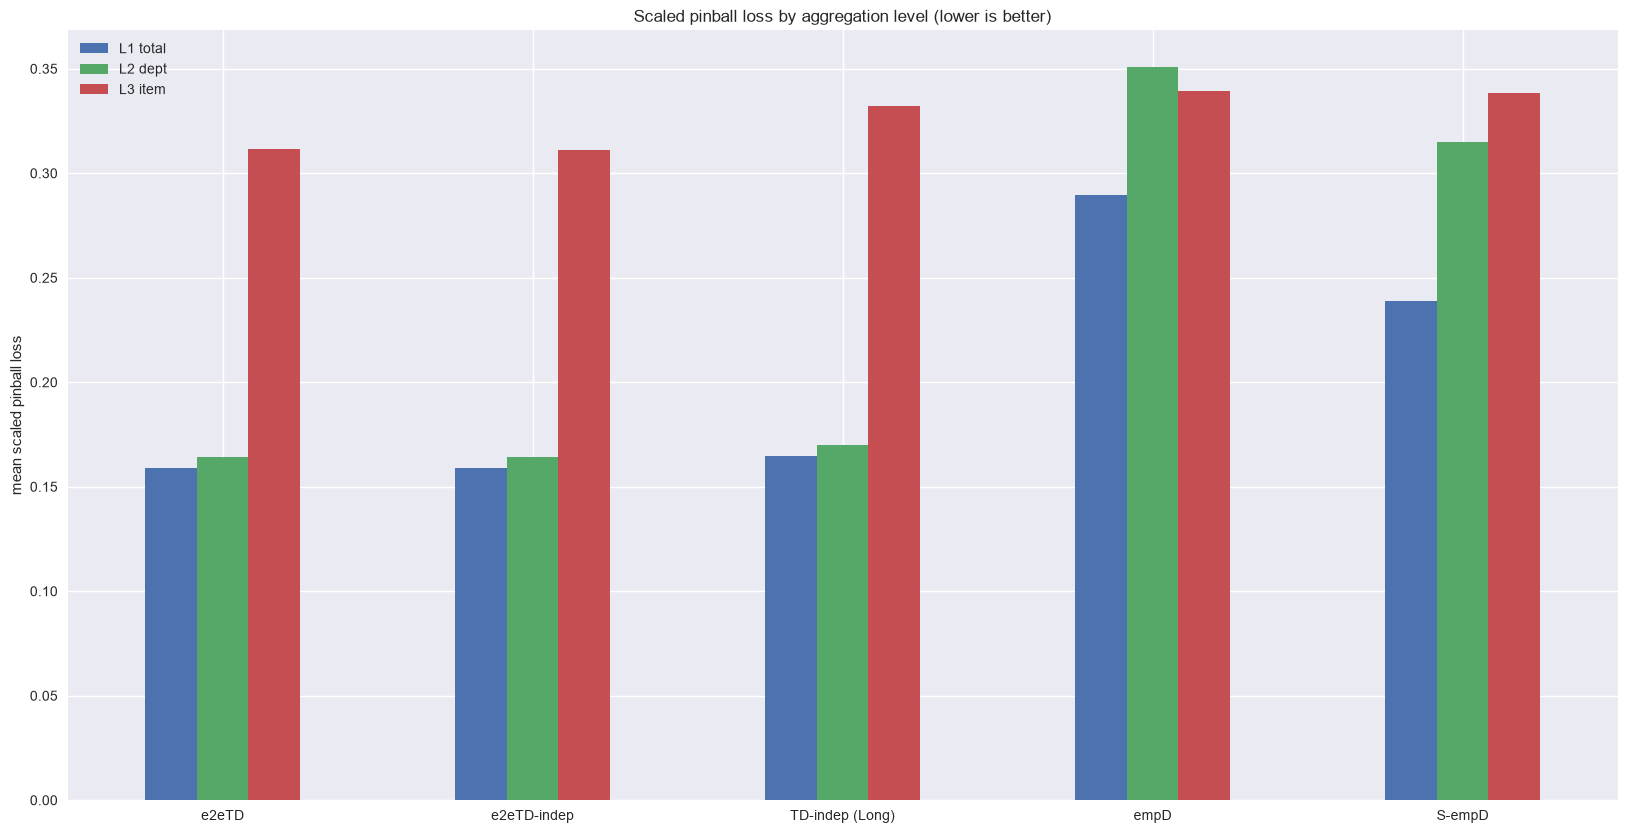

In [34]:
results_df[['L1 total', 'L2 dept', 'L3 item']].plot(kind='bar', rot=0)
plt.title('Scaled pinball loss by aggregation level (lower is better)')
plt.ylabel('mean scaled pinball loss')
plt.show()

The same numbers as a grouped bar chart, one cluster per method, one bar per level. Two shapes to notice. For every method the bottom level (L3) is the hardest — intermittent items are simply less predictable than their aggregates, even after scaling. And the methods differ most at L1/L2: the top of the hierarchy is where modelling dynamics (trend, seasonality, growing uncertainty) pays, which is exactly where e2eTD spends its entire modelling budget. The e2eTD and e2eTD-indep clusters are visually identical — the ablation in one picture.

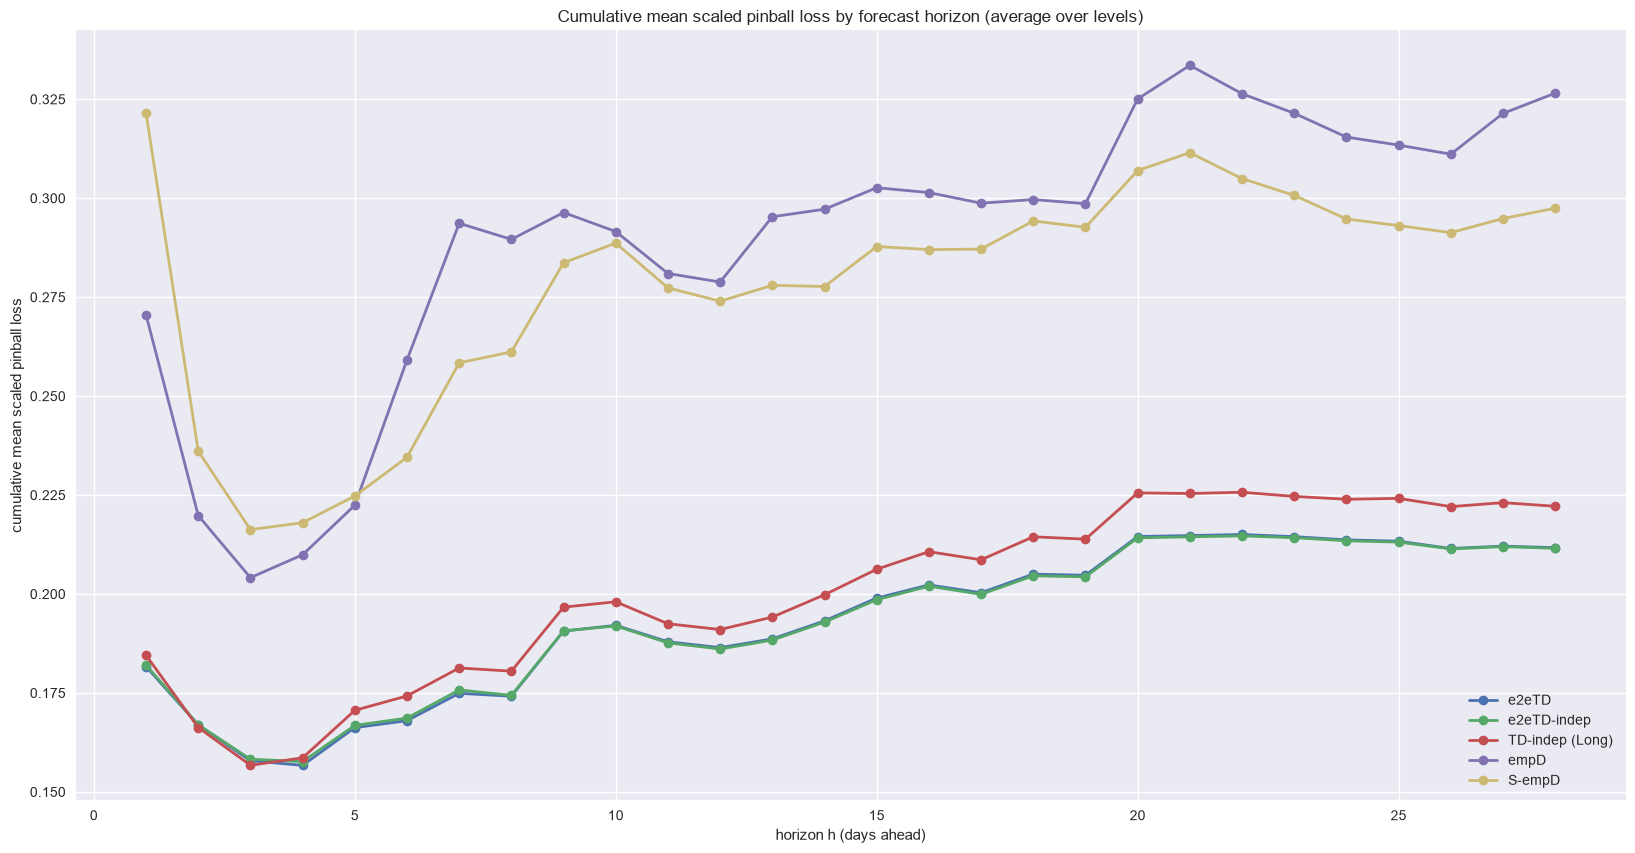

In [35]:
for label, curve in curves.items():
    plt.plot(np.arange(1, CFG.HORIZON + 1), curve, linewidth=2, marker='o', label=label)
plt.title('Cumulative mean scaled pinball loss by forecast horizon (average over levels)')
plt.xlabel('horizon h (days ahead)')
plt.ylabel('cumulative mean scaled pinball loss')
plt.legend()
plt.show()

The horizon diagnostic, mirroring the paper's Figure 7: at each h we plot the average score over horizons 1..h, so the curves stabilize as they absorb more days. Every curve has its minimum within the first few days (the days right after the training cutoff resemble the recent past) and drifts upward from there. The e2eTD curves stay at the bottom across the whole four weeks; the static baselines start much higher. Long-style top-down is the interesting one: competitive early, deteriorating relative to e2eTD as h grows — its bottom-level variance is a *static* in-sample estimate, while e2eTD inherits the horizon-dependent, widening predictive variance of the upper-level ETS fans. Uncertainty that grows with horizon is a feature you get for free from forecasting the top properly.

# Wrap-up

We rebuilt, in a few hundred lines of NumPy, the complete e2eTD pipeline from Zambon, Azzimonti & Corani (2026): ETS forecasts for **three** upper series, Gaussian reconciliation by linear-constraint conditioning, and a recursive probabilistic top-down sampler — count marginals by weighted moment matching, dependence by a Plackett copula calibrated through Spearman's ρ, splits drawn from the joint distribution conditioned on the parent total. The result: 14,000 exactly coherent scenarios for 565 series in about three seconds, and the best scaled pinball loss at every level of our M5 slice.

What the exercise teaches, beyond the algorithm:

- **Forecast where the signal is.** ~0.5% of the hierarchy received a model; the intermittent 99.5% were handled by in-sample distributions. That allocation of effort, not any single clever component, is why the method is simultaneously accurate and fast.
- **Coherence by construction beats coherence by correction.** Splitting samples top-down preserves the aggregation constraints exactly at every step — no projection, no post-hoc adjustment, no possibility of negative or fractional "reconciled" counts.
- **Probabilistic proportions are the novelty.** Classical top-down's fixed proportions collapse split uncertainty; here the historical proportions become a joint distribution, so bottom-level forecasts carry honest spread and natural intermittency.
- **Ablate before you believe.** The elegant copula machinery was worth essentially nothing on this dataset — as the paper itself reports for M5 — while the humble reconciliation step and the exogenous regressors (which we skipped) are worth several percent.

What the full paper adds beyond our minimal version: crossed (grouped) hierarchies with 12–16 aggregation levels, exogenous regressors in the ETS models (SNAP, holidays, promotions), recency-weighted dependence estimation, parallelization, and the full benchmark — where e2eTD achieves the best mean WSPL on both M5 and Favorita among all scalable coherent methods, and would have placed 11th of 892 teams in the M5 Uncertainty competition. Natural extensions they flag: principled selection of which uppers to forecast, and replacing static in-sample proportions with dynamic models for the (few) bottom series that do carry temporal signal.